# US Births Time Series Analysis: Complete Presentation
## A Comprehensive Analysis of Daily Births in the United States (1969-1988)

**Author:** Time Series Analysis Project  
**Date:** December 2025

---

### Analysis Overview

This notebook presents a complete time series analysis of daily birth data in the United States spanning from 1969 to 1988. We employ multiple advanced statistical techniques including:

- **Data Preparation & Exploration**
- **Stationarity Testing** (ADF, KPSS, Ljung-Box)
- **Seasonal Pattern Analysis**
- **Spectral Analysis** (Fourier Transform)
- **Wavelet Analysis** (Time-Frequency Decomposition)
- **SARIMA Modeling** (Seasonal ARIMA)
- **Multiple Seasonality Handling** (Fourier Terms as Exogenous Variables)
- **Model Validation & Forecasting**

---

## Step 0: Import Required Libraries

In [1]:
# Standard libraries
from datasets import load_dataset
import duckdb as ddb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Statistical analysis
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Spectral/Wavelet analysis
from scipy import signal, fft
import pywt

# Custom utilities
import utilities.arima_analysis as arima
import utilities.sarima_analysis as sarima
import utilities.spectral_analysis as spectral
import utilities.time_subset as tsub

# Plotting configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16

print("✓ All libraries imported successfully")
print(f"✓ Analysis date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✓ All libraries imported successfully
✓ Analysis date: 2025-12-05 05:54


---
## Step 1: Download and Load Data

We download the US Births dataset from the UTSD (Unified Time Series Dataset) collection.

In [2]:
print("="*80)
print("STEP 1: DOWNLOADING DATA")
print("="*80)

# Load UTSD dataset
print("\nLoading UTSD dataset from Hugging Face...")
ds = load_dataset("thuml/UTSD", "UTSD-1G")
df = pd.DataFrame(ds['train'])

# Connect to DuckDB for efficient querying
con = ddb.connect()

print(f"✓ Dataset loaded: {len(df):,} time series")

# Filter for US births data
us_births_df = con.execute("""
    SELECT * FROM df WHERE item_id LIKE '%birth%';
""").fetch_df()

print(f"✓ Found {len(us_births_df)} US births time series")
print("\nDataset preview:")
us_births_df.head()

STEP 1: DOWNLOADING DATA

Loading UTSD dataset from Hugging Face...


Resolving data files:   0%|          | 0/320 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

✓ Dataset loaded: 68,679 time series


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ Found 1 US births time series

Dataset preview:


,item_id,start,end,freq,target
0,Nature_us_births_dataset_0_0,1969-01-01T00:00:00.000000000,1988-12-31T00:00:00.000000000,D,"[8486.0, 9002.0, 9542.0, 8960.0, 8390.0, 9560...."


---
## Step 2: Data Preparation and Formatting

Convert the raw data into a properly formatted time series DataFrame.

In [3]:
print("="*80)
print("STEP 2: DATA PREPARATION")
print("="*80)

# Extract the time series data
birth_row = us_births_df.iloc[0]
item_id = birth_row['item_id']
start_date = pd.to_datetime(birth_row['start'])
end_date = pd.to_datetime(birth_row['end'])
freq = birth_row['freq']
target_values = birth_row['target']

print(f"\nTime Series Information:")
print(f"  • Item ID: {item_id}")
print(f"  • Start Date: {start_date.date()}")
print(f"  • End Date: {end_date.date()}")
print(f"  • Frequency: {freq} (Daily)")
print(f"  • Observations: {len(target_values):,}")

# Create date range
date_range = pd.date_range(start=start_date, periods=len(target_values), freq='D')

# Create comprehensive DataFrame
births_df = pd.DataFrame({
    'datetime': date_range,
    'births': target_values
})

# Extract useful date features
births_df['year'] = births_df['datetime'].dt.year
births_df['month'] = births_df['datetime'].dt.month
births_df['day'] = births_df['datetime'].dt.day
births_df['day_of_week'] = births_df['datetime'].dt.dayofweek
births_df['day_name'] = births_df['datetime'].dt.day_name()
births_df['month_name'] = births_df['datetime'].dt.month_name()
births_df['is_weekend'] = births_df['day_of_week'].isin([5, 6]).astype(int)

print(f"\n✓ DataFrame created with {len(births_df):,} observations")
print(f"✓ Date range: {births_df['datetime'].min().date()} to {births_df['datetime'].max().date()}")
print(f"✓ Duration: {(births_df['datetime'].max() - births_df['datetime'].min()).days} days")

print("\nData Summary Statistics:")
print(f"  • Mean births/day: {births_df['births'].mean():.2f}")
print(f"  • Median births/day: {births_df['births'].median():.2f}")
print(f"  • Std deviation: {births_df['births'].std():.2f}")
print(f"  • Min births/day: {births_df['births'].min():.0f}")
print(f"  • Max births/day: {births_df['births'].max():.0f}")
print(f"  • Total births: {births_df['births'].sum():,.0f}")

print("\nFirst few rows:")
births_df.head(10)

STEP 2: DATA PREPARATION

Time Series Information:
  • Item ID: Nature_us_births_dataset_0_0
  • Start Date: 1969-01-01
  • End Date: 1988-12-31
  • Frequency: D (Daily)
  • Observations: 7,305

✓ DataFrame created with 7,305 observations
✓ Date range: 1969-01-01 to 1988-12-31
✓ Duration: 7304 days

Data Summary Statistics:
  • Mean births/day: 9648.94
  • Median births/day: 9622.00
  • Std deviation: 1127.32
  • Min births/day: 6675
  • Max births/day: 12851
  • Total births: 70,485,508

First few rows:


,datetime,births,year,month,day,day_of_week,day_name,month_name,is_weekend
0,1969-01-01,8486.0,1969,1,1,2,Wednesday,January,0
1,1969-01-02,9002.0,1969,1,2,3,Thursday,January,0
2,1969-01-03,9542.0,1969,1,3,4,Friday,January,0
3,1969-01-04,8960.0,1969,1,4,5,Saturday,January,1
4,1969-01-05,8390.0,1969,1,5,6,Sunday,January,1
5,1969-01-06,9560.0,1969,1,6,0,Monday,January,0
6,1969-01-07,9738.0,1969,1,7,1,Tuesday,January,0
7,1969-01-08,9734.0,1969,1,8,2,Wednesday,January,0
8,1969-01-09,9434.0,1969,1,9,3,Thursday,January,0
9,1969-01-10,10042.0,1969,1,10,4,Friday,January,0


---
## Step 3: Split Data into Training and Test Sets

We use:
- **Training data**: 1974-01-01 to 1987-12-31 (14 years)
- **Test data**: 1988-01-01 to 1988-12-31 (1 year)

In [4]:
print("="*80)
print("STEP 3: TRAIN/TEST SPLIT")
print("="*80)

# Extract recent data (1974-1988)
recent_data = tsub.extract_subset(
    births_df,
    datetime_col='datetime',
    start_date='1974-01-01',
    end_date='1988-12-31'
)

# Split into train (1974-1987) and test (1988)
train_df = tsub.extract_subset(
    recent_data,
    datetime_col='datetime',
    start_date='1974-01-01',
    end_date='1987-12-31'
)

test_df = tsub.extract_subset(
    recent_data,
    datetime_col='datetime',
    start_date='1988-01-01',
    end_date='1988-12-31'
)

print(f"\nData Split Summary:")
print(f"  • Training set: {len(train_df):,} observations ({train_df['datetime'].min().date()} to {train_df['datetime'].max().date()})")
print(f"  • Test set: {len(test_df):,} observations ({test_df['datetime'].min().date()} to {test_df['datetime'].max().date()})")
print(f"  • Train/Test ratio: {len(train_df)/len(test_df):.1f}:1")

STEP 3: TRAIN/TEST SPLIT

TIME SUBSET VALIDATION
Requested start: 1974-01-01 00:00:00
Actual start:    1974-01-01 00:00:00
Requested end:   1988-12-31 00:00:00
Actual end:      1988-12-31 00:00:00
Total records:   5479
Date range:      5478 days
✓ No gaps detected in time series


TIME SUBSET VALIDATION
Requested start: 1974-01-01 00:00:00
Actual start:    1974-01-01 00:00:00
Requested end:   1987-12-31 00:00:00
Actual end:      1987-12-31 00:00:00
Total records:   5113
Date range:      5112 days
✓ No gaps detected in time series


TIME SUBSET VALIDATION
Requested start: 1988-01-01 00:00:00
Actual start:    1988-01-01 00:00:00
Requested end:   1988-12-31 00:00:00
Actual end:      1988-12-31 00:00:00
Total records:   366
Date range:      365 days
✓ No gaps detected in time series


Data Split Summary:
  • Training set: 5,113 observations (1974-01-01 to 1987-12-31)
  • Test set: 366 observations (1988-01-01 to 1988-12-31)
  • Train/Test ratio: 14.0:1


---
## Step 4: Visualize Training and Test Data

Beautiful, publication-quality visualizations of the data.

STEP 4: DATA VISUALIZATION


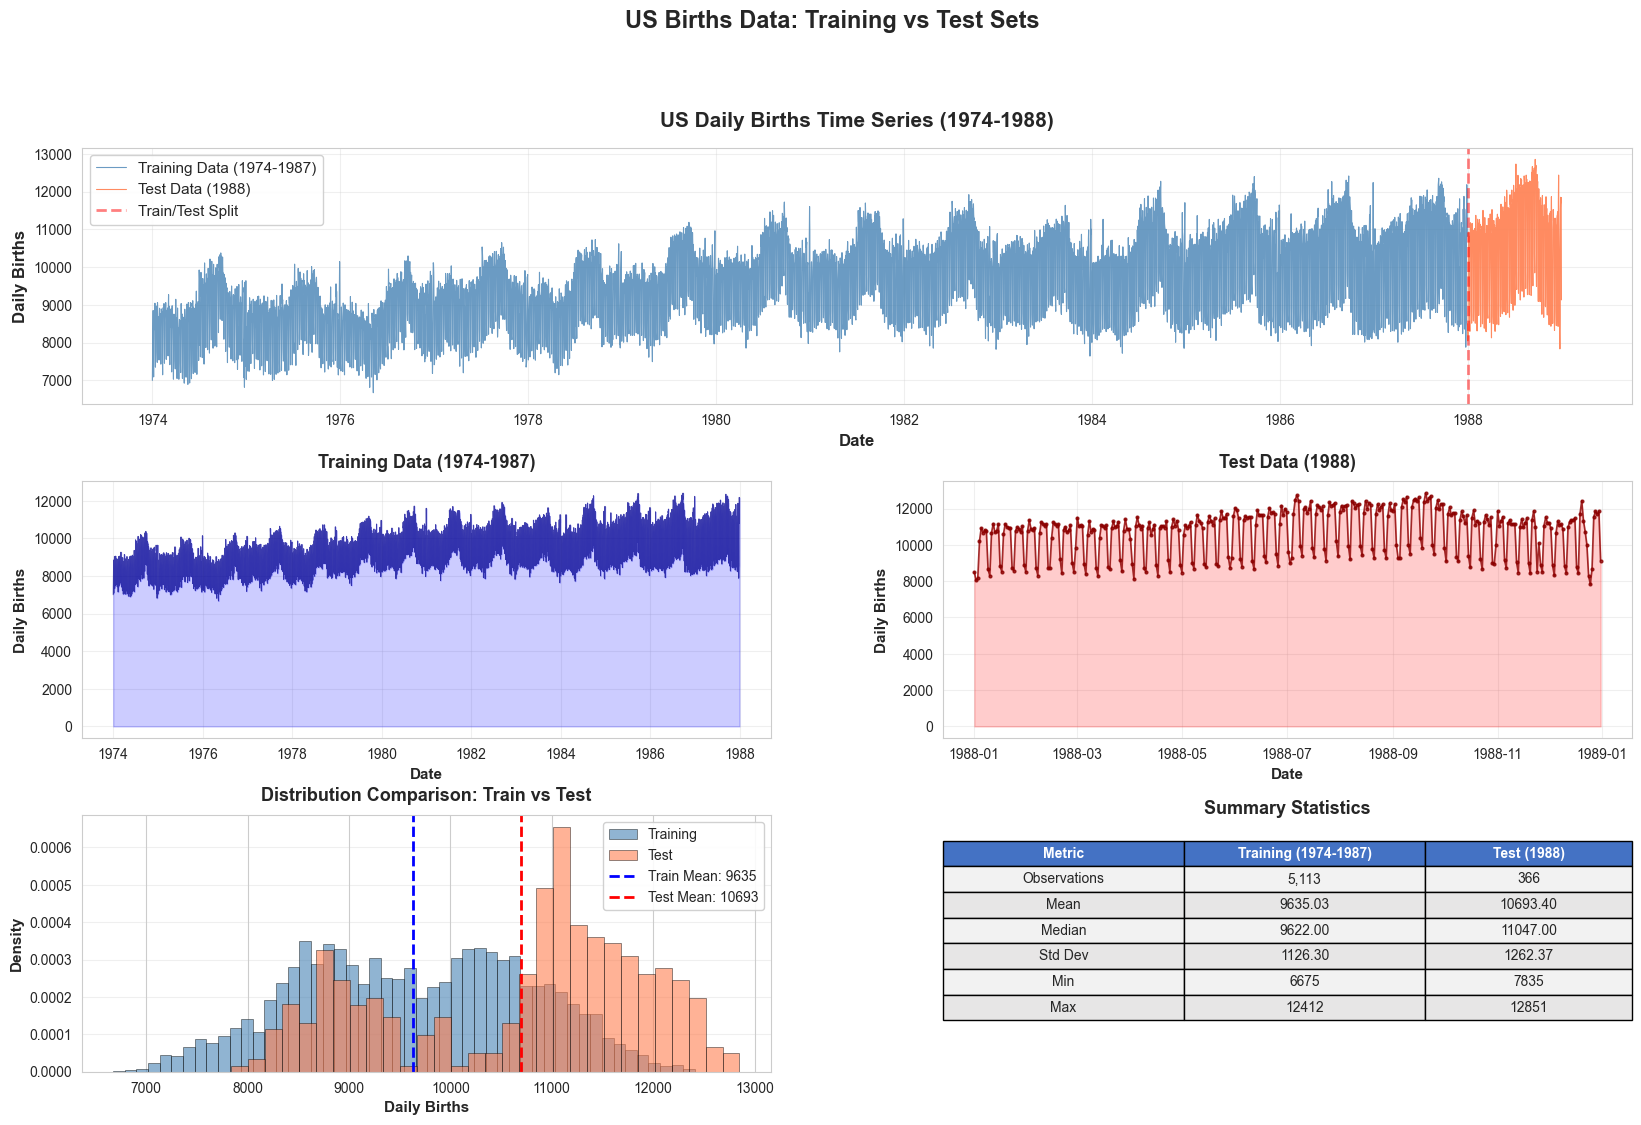


✓ Visualization complete


In [5]:
print("="*80)
print("STEP 4: DATA VISUALIZATION")
print("="*80)

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.25)

# 1. Full time series with train/test split highlighted
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(train_df['datetime'], train_df['births'],
         linewidth=0.8, color='steelblue', alpha=0.8, label='Training Data (1974-1987)')
ax1.plot(test_df['datetime'], test_df['births'],
         linewidth=0.8, color='coral', alpha=0.9, label='Test Data (1988)')
ax1.axvline(x=test_df['datetime'].min(), color='red', linestyle='--', linewidth=2, alpha=0.5, label='Train/Test Split')
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Daily Births', fontsize=12, fontweight='bold')
ax1.set_title('US Daily Births Time Series (1974-1988)', fontsize=15, fontweight='bold', pad=15)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# 2. Training data only (zoomed)
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(train_df['datetime'], train_df['births'],
         linewidth=0.7, color='darkblue', alpha=0.7)
ax2.fill_between(train_df['datetime'], train_df['births'], alpha=0.2, color='blue')
ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('Daily Births', fontsize=11, fontweight='bold')
ax2.set_title('Training Data (1974-1987)', fontsize=13, fontweight='bold', pad=10)
ax2.grid(True, alpha=0.3)

# 3. Test data only (zoomed)
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(test_df['datetime'], test_df['births'],
         linewidth=1.2, color='darkred', alpha=0.8, marker='o', markersize=2)
ax3.fill_between(test_df['datetime'], test_df['births'], alpha=0.2, color='red')
ax3.set_xlabel('Date', fontsize=11, fontweight='bold')
ax3.set_ylabel('Daily Births', fontsize=11, fontweight='bold')
ax3.set_title('Test Data (1988)', fontsize=13, fontweight='bold', pad=10)
ax3.grid(True, alpha=0.3)

# 4. Distribution comparison
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(train_df['births'], bins=50, alpha=0.6, color='steelblue', label='Training', density=True, edgecolor='black', linewidth=0.5)
ax4.hist(test_df['births'], bins=30, alpha=0.6, color='coral', label='Test', density=True, edgecolor='black', linewidth=0.5)
ax4.axvline(train_df['births'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Train Mean: {train_df["births"].mean():.0f}')
ax4.axvline(test_df['births'].mean(), color='red', linestyle='--', linewidth=2, label=f'Test Mean: {test_df["births"].mean():.0f}')
ax4.set_xlabel('Daily Births', fontsize=11, fontweight='bold')
ax4.set_ylabel('Density', fontsize=11, fontweight='bold')
ax4.set_title('Distribution Comparison: Train vs Test', fontsize=13, fontweight='bold', pad=10)
ax4.legend(fontsize=10, framealpha=0.9)
ax4.grid(True, alpha=0.3, axis='y')

# 5. Summary statistics table
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')

stats_data = [
    ['Metric', 'Training (1974-1987)', 'Test (1988)'],
    ['Observations', f"{len(train_df):,}", f"{len(test_df):,}"],
    ['Mean', f"{train_df['births'].mean():.2f}", f"{test_df['births'].mean():.2f}"],
    ['Median', f"{train_df['births'].median():.2f}", f"{test_df['births'].median():.2f}"],
    ['Std Dev', f"{train_df['births'].std():.2f}", f"{test_df['births'].std():.2f}"],
    ['Min', f"{train_df['births'].min():.0f}", f"{test_df['births'].min():.0f}"],
    ['Max', f"{train_df['births'].max():.0f}", f"{test_df['births'].max():.0f}"]
]

table = ax5.table(cellText=stats_data, cellLoc='center', loc='center',
                  colWidths=[0.35, 0.35, 0.3],
                  bbox=[0, 0.2, 1, 0.7])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header row
for i in range(3):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(stats_data)):
    for j in range(3):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')
        else:
            table[(i, j)].set_facecolor('#F2F2F2')

ax5.set_title('Summary Statistics', fontsize=13, fontweight='bold', pad=10, y=0.95)

plt.suptitle('US Births Data: Training vs Test Sets', fontsize=17, fontweight='bold', y=0.995)
plt.show()

print("\n✓ Visualization complete")

---
## Step 5: Stationarity Testing

We perform three statistical tests:
1. **Augmented Dickey-Fuller (ADF)**: Tests for unit root (null hypothesis: non-stationary)
2. **KPSS**: Tests for stationarity (null hypothesis: stationary)
3. **Ljung-Box**: Tests for autocorrelation in residuals

We test on:
- Original series
- 1st order differenced series
- 2nd order differenced series

In [6]:
print("="*80)
print("STEP 5: STATIONARITY TESTING")
print("="*80)

# Prepare series
original_series = train_df['births'].values
diff1_series = np.diff(original_series, n=1)
diff2_series = np.diff(original_series, n=2)

def perform_comprehensive_stationarity_tests(series, name):
    """
    Perform ADF, KPSS, and Ljung-Box tests
    """
    print(f"\n{'='*80}")
    print(f"STATIONARITY TESTS: {name}")
    print(f"{'='*80}")

    # 1. Augmented Dickey-Fuller Test
    print("\n1. Augmented Dickey-Fuller (ADF) Test")
    print("-" * 60)
    adf_result = adfuller(series, autolag='AIC')
    print(f"   ADF Statistic: {adf_result[0]:.6f}")
    print(f"   p-value: {adf_result[1]:.6f}")
    print(f"   Lags Used: {adf_result[2]}")
    print(f"   Observations: {adf_result[3]}")
    print(f"\n   Critical Values:")
    for key, value in adf_result[4].items():
        print(f"      {key}: {value:.3f}")

    if adf_result[1] <= 0.05:
        print(f"\n   ✓ Result: STATIONARY (reject null hypothesis, p={adf_result[1]:.6f})")
        adf_conclusion = "Stationary"
    else:
        print(f"\n   ✗ Result: NON-STATIONARY (fail to reject null hypothesis, p={adf_result[1]:.6f})")
        adf_conclusion = "Non-Stationary"

    # 2. KPSS Test
    print("\n2. Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test")
    print("-" * 60)
    kpss_result = kpss(series, regression='c', nlags='auto')
    print(f"   KPSS Statistic: {kpss_result[0]:.6f}")
    print(f"   p-value: {kpss_result[1]:.6f}")
    print(f"   Lags Used: {kpss_result[2]}")
    print(f"\n   Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"      {key}: {value:.3f}")

    if kpss_result[1] >= 0.05:
        print(f"\n   ✓ Result: STATIONARY (fail to reject null hypothesis, p={kpss_result[1]:.6f})")
        kpss_conclusion = "Stationary"
    else:
        print(f"\n   ✗ Result: NON-STATIONARY (reject null hypothesis, p={kpss_result[1]:.6f})")
        kpss_conclusion = "Non-Stationary"

    # 3. Ljung-Box Test (for autocorrelation)
    print("\n3. Ljung-Box Test (Autocorrelation)")
    print("-" * 60)
    lb_result = acorr_ljungbox(series, lags=[10, 20, 30], return_df=True)
    print(lb_result)

    if (lb_result['lb_pvalue'] < 0.05).any():
        print(f"\n   ✓ Result: AUTOCORRELATION DETECTED (p < 0.05 for some lags)")
        lb_conclusion = "Autocorrelated"
    else:
        print(f"\n   ✗ Result: NO AUTOCORRELATION (p >= 0.05 for all lags)")
        lb_conclusion = "No Autocorrelation"

    # Summary
    print(f"\n{'='*80}")
    print(f"SUMMARY FOR {name}")
    print(f"{'='*80}")
    print(f"   ADF Test: {adf_conclusion}")
    print(f"   KPSS Test: {kpss_conclusion}")
    print(f"   Ljung-Box Test: {lb_conclusion}")

    return {
        'adf': adf_conclusion,
        'kpss': kpss_conclusion,
        'ljungbox': lb_conclusion
    }

# Test all three series
results_original = perform_comprehensive_stationarity_tests(original_series, "ORIGINAL SERIES")
results_diff1 = perform_comprehensive_stationarity_tests(diff1_series, "1ST ORDER DIFFERENCED")
results_diff2 = perform_comprehensive_stationarity_tests(diff2_series, "2ND ORDER DIFFERENCED")

STEP 5: STATIONARITY TESTING

STATIONARITY TESTS: ORIGINAL SERIES

1. Augmented Dickey-Fuller (ADF) Test
------------------------------------------------------------
   ADF Statistic: -3.019237
   p-value: 0.033137
   Lags Used: 33
   Observations: 5079

   Critical Values:
      1%: -3.432
      5%: -2.862
      10%: -2.567

   ✓ Result: STATIONARY (reject null hypothesis, p=0.033137)

2. Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test
------------------------------------------------------------
   KPSS Statistic: 9.491805
   p-value: 0.010000
   Lags Used: 38

   Critical Values:
      10%: 0.347
      5%: 0.463
      2.5%: 0.574
      1%: 0.739

   ✗ Result: NON-STATIONARY (reject null hypothesis, p=0.010000)

3. Ljung-Box Test (Autocorrelation)
------------------------------------------------------------
         lb_stat  lb_pvalue
10  11266.348736        0.0
20  21866.271940        0.0
30  35694.305413        0.0

   ✓ Result: AUTOCORRELATION DETECTED (p < 0.05 for some lags)

SUMMA

STATIONARITY AND AUTOCORRELATION ANALYSIS

STATISTICAL TEST SUMMARY

Original Data:
  ADF Test: p-value = 0.033137 → Stationary
  KPSS Test: p-value = 0.010000 → Non-stationary
  Ljung-Box: 20 significant lags → Autocorrelated

1st Order Differenced:
  ADF Test: p-value = 0.000000 → Stationary
  KPSS Test: p-value = 0.100000 → Stationary
  Ljung-Box: 19 significant lags → Autocorrelated

2nd Order Differenced:
  ADF Test: p-value = 0.000000 → Stationary
  KPSS Test: p-value = 0.100000 → Stationary
  Ljung-Box: 20 significant lags → Autocorrelated


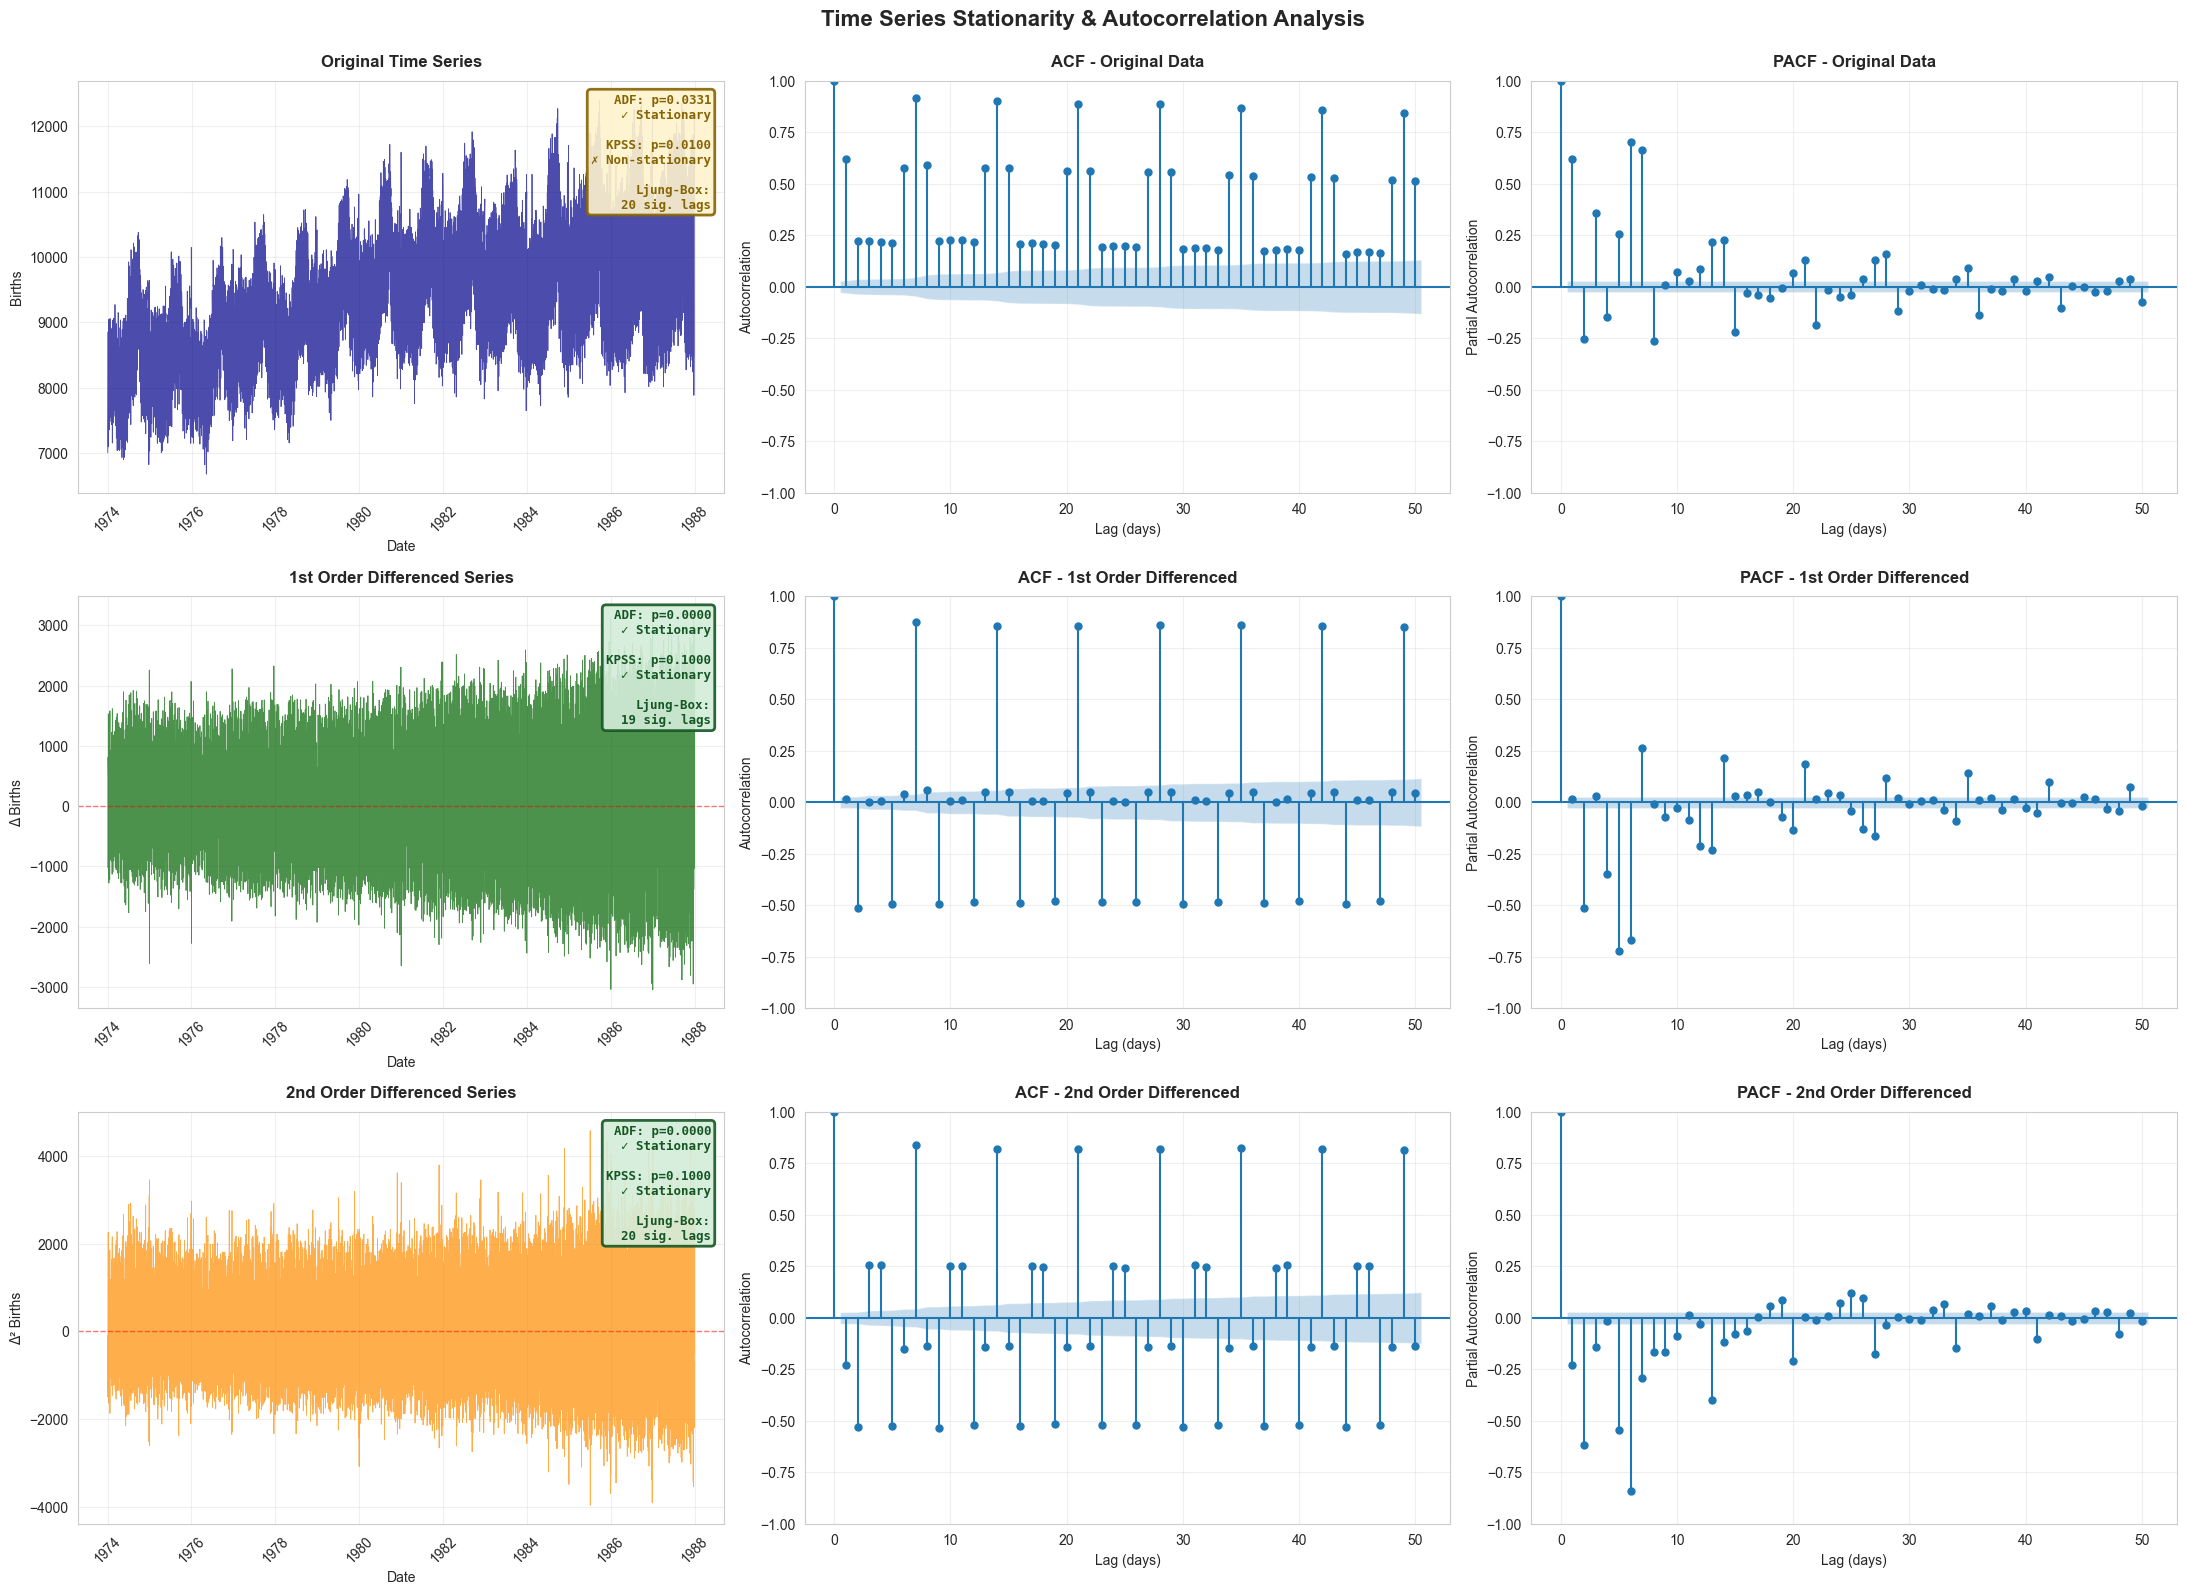


DESCRIPTIVE STATISTICS

Metric                    Original        1st Diff        2nd Diff       
----------------------------------------------------------------------
Mean                             9635.03       0.745305      -0.359617
Std Dev                          1126.30         983.98        1380.46
Variance                      1268547.42      968207.71     1905676.56
Min                              6675.00       -3045.00       -3964.00
Max                             12412.00        3171.00        4579.00
Observations                        5113           5112           5111

MODELING RECOMMENDATION

✓ RECOMMENDATION: Use d=1 (1st order differencing)
  → Both ADF and KPSS tests confirm stationarity after first differencing
  → This is the optimal differencing order for SARIMA modeling

KEY OBSERVATIONS FOR SARIMA PARAMETER SELECTION

1. DIFFERENCING (d):
   → d=1 achieves stationarity

2. AUTOREGRESSIVE ORDER (p):
   → Examine PACF cutoff points to determine AR order
   →

In [8]:
# ACF and PACF Analysis with Statistical Tests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

print("="*70)
print("STATIONARITY AND AUTOCORRELATION ANALYSIS")
print("="*70)

# Prepare data
original_data = train_df['births']
diff_1st = original_data.diff().dropna()
diff_2nd = original_data.diff().diff().dropna()

# Function to perform ADF test
def perform_adf_test(data):
    result = adfuller(data, autolag='AIC')
    return {
        'statistic': result[0],
        'pvalue': result[1],
        'critical_1%': result[4]['1%'],
        'critical_5%': result[4]['5%'],
        'stationary': result[1] < 0.05
    }

# Function to perform KPSS test
def perform_kpss_test(data):
    result = kpss(data, regression='ct', nlags='auto')
    return {
        'statistic': result[0],
        'pvalue': result[1],
        'critical_1%': result[3]['1%'],
        'critical_5%': result[3]['5%'],
        'stationary': result[1] > 0.05
    }

# Function to perform Ljung-Box test
def perform_ljungbox_test(data, lags=20):
    result = acorr_ljungbox(data, lags=lags, return_df=True)
    significant_lags = result[result['lb_pvalue'] < 0.05]
    return {
        'n_significant': len(significant_lags),
        'autocorrelated': len(significant_lags) > 0
    }

# Perform all tests
tests_original = {
    'adf': perform_adf_test(original_data),
    'kpss': perform_kpss_test(original_data),
    'lb': perform_ljungbox_test(original_data)
}

tests_1st = {
    'adf': perform_adf_test(diff_1st),
    'kpss': perform_kpss_test(diff_1st),
    'lb': perform_ljungbox_test(diff_1st)
}

tests_2nd = {
    'adf': perform_adf_test(diff_2nd),
    'kpss': perform_kpss_test(diff_2nd),
    'lb': perform_ljungbox_test(diff_2nd)
}

# Print summary to console
print("\n" + "="*70)
print("STATISTICAL TEST SUMMARY")
print("="*70)

def print_test_summary(name, tests):
    print(f"\n{name}:")
    print(f"  ADF Test: p-value = {tests['adf']['pvalue']:.6f} → {'Stationary' if tests['adf']['stationary'] else 'Non-stationary'}")
    print(f"  KPSS Test: p-value = {tests['kpss']['pvalue']:.6f} → {'Stationary' if tests['kpss']['stationary'] else 'Non-stationary'}")
    print(f"  Ljung-Box: {tests['lb']['n_significant']} significant lags → {'Autocorrelated' if tests['lb']['autocorrelated'] else 'No autocorrelation'}")

print_test_summary("Original Data", tests_original)
print_test_summary("1st Order Differenced", tests_1st)
print_test_summary("2nd Order Differenced", tests_2nd)
print("="*70)

# Create 3x3 figure
fig, axes = plt.subplots(3, 3, figsize=(22, 16))
fig.suptitle('Time Series Stationarity & Autocorrelation Analysis',
             fontsize=16, fontweight='bold', y=0.995)

# Helper function to add test results as text box
def add_test_box(ax, tests, position='upper right'):
    adf_status = '✓ Stationary' if tests['adf']['stationary'] else '✗ Non-stationary'
    kpss_status = '✓ Stationary' if tests['kpss']['stationary'] else '✗ Non-stationary'

    textstr = f"ADF: p={tests['adf']['pvalue']:.4f}\n{adf_status}\n\n"
    textstr += f"KPSS: p={tests['kpss']['pvalue']:.4f}\n{kpss_status}\n\n"
    textstr += f"Ljung-Box:\n{tests['lb']['n_significant']} sig. lags"

    # Color based on stationarity
    if tests['adf']['stationary'] and tests['kpss']['stationary']:
        bbox_color = '#d4edda'  # light green
        text_color = '#155724'
    elif not tests['adf']['stationary'] and not tests['kpss']['stationary']:
        bbox_color = '#f8d7da'  # light red
        text_color = '#721c24'
    else:
        bbox_color = '#fff3cd'  # light yellow
        text_color = '#856404'

    props = dict(boxstyle='round', facecolor=bbox_color, alpha=0.9, edgecolor=text_color, linewidth=2)
    ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=props, fontfamily='monospace', color=text_color, fontweight='bold')

# ROW 1: Original Data
# Time series plot
axes[0, 0].plot(train_df['datetime'], original_data, linewidth=0.6, color='darkblue', alpha=0.7)
axes[0, 0].set_title('Original Time Series', fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Date', fontsize=10)
axes[0, 0].set_ylabel('Births', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)
add_test_box(axes[0, 0], tests_original)

# ACF
plot_acf(original_data, lags=50, ax=axes[0, 1], alpha=0.05)
axes[0, 1].set_title('ACF - Original Data', fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Lag (days)', fontsize=10)
axes[0, 1].set_ylabel('Autocorrelation', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# PACF
plot_pacf(original_data, lags=50, ax=axes[0, 2], alpha=0.05, method='ywm')
axes[0, 2].set_title('PACF - Original Data', fontsize=12, fontweight='bold', pad=10)
axes[0, 2].set_xlabel('Lag (days)', fontsize=10)
axes[0, 2].set_ylabel('Partial Autocorrelation', fontsize=10)
axes[0, 2].grid(True, alpha=0.3)

# ROW 2: 1st Order Differenced
# Time series plot
datetime_diff1 = train_df['datetime'].iloc[1:]
axes[1, 0].plot(datetime_diff1, diff_1st, linewidth=0.6, color='darkgreen', alpha=0.7)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
axes[1, 0].set_title('1st Order Differenced Series', fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Date', fontsize=10)
axes[1, 0].set_ylabel('Δ Births', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)
add_test_box(axes[1, 0], tests_1st)

# ACF
plot_acf(diff_1st, lags=50, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF - 1st Order Differenced', fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Lag (days)', fontsize=10)
axes[1, 1].set_ylabel('Autocorrelation', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# PACF
plot_pacf(diff_1st, lags=50, ax=axes[1, 2], alpha=0.05, method='ywm')
axes[1, 2].set_title('PACF - 1st Order Differenced', fontsize=12, fontweight='bold', pad=10)
axes[1, 2].set_xlabel('Lag (days)', fontsize=10)
axes[1, 2].set_ylabel('Partial Autocorrelation', fontsize=10)
axes[1, 2].grid(True, alpha=0.3)

# ROW 3: 2nd Order Differenced
# Time series plot
datetime_diff2 = train_df['datetime'].iloc[2:]
axes[2, 0].plot(datetime_diff2, diff_2nd, linewidth=0.6, color='darkorange', alpha=0.7)
axes[2, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
axes[2, 0].set_title('2nd Order Differenced Series', fontsize=12, fontweight='bold', pad=10)
axes[2, 0].set_xlabel('Date', fontsize=10)
axes[2, 0].set_ylabel('Δ² Births', fontsize=10)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].tick_params(axis='x', rotation=45)
add_test_box(axes[2, 0], tests_2nd)

# ACF
plot_acf(diff_2nd, lags=50, ax=axes[2, 1], alpha=0.05)
axes[2, 1].set_title('ACF - 2nd Order Differenced', fontsize=12, fontweight='bold', pad=10)
axes[2, 1].set_xlabel('Lag (days)', fontsize=10)
axes[2, 1].set_ylabel('Autocorrelation', fontsize=10)
axes[2, 1].grid(True, alpha=0.3)

# PACF
plot_pacf(diff_2nd, lags=50, ax=axes[2, 2], alpha=0.05, method='ywm')
axes[2, 2].set_title('PACF - 2nd Order Differenced', fontsize=12, fontweight='bold', pad=10)
axes[2, 2].set_xlabel('Lag (days)', fontsize=10)
axes[2, 2].set_ylabel('Partial Autocorrelation', fontsize=10)
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Descriptive Statistics Table
print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS")
print("="*70)
print(f"\n{'Metric':<25} {'Original':<15} {'1st Diff':<15} {'2nd Diff':<15}")
print("-" * 70)
print(f"{'Mean':<25} {original_data.mean():>14.2f} {diff_1st.mean():>14.6f} {diff_2nd.mean():>14.6f}")
print(f"{'Std Dev':<25} {original_data.std():>14.2f} {diff_1st.std():>14.2f} {diff_2nd.std():>14.2f}")
print(f"{'Variance':<25} {original_data.var():>14.2f} {diff_1st.var():>14.2f} {diff_2nd.var():>14.2f}")
print(f"{'Min':<25} {original_data.min():>14.2f} {diff_1st.min():>14.2f} {diff_2nd.min():>14.2f}")
print(f"{'Max':<25} {original_data.max():>14.2f} {diff_1st.max():>14.2f} {diff_2nd.max():>14.2f}")
print(f"{'Observations':<25} {len(original_data):>14} {len(diff_1st):>14} {len(diff_2nd):>14}")
print("="*70)

# Final Recommendation
print("\n" + "="*70)
print("MODELING RECOMMENDATION")
print("="*70)

if tests_1st['adf']['stationary'] and tests_1st['kpss']['stationary']:
    print("\n✓ RECOMMENDATION: Use d=1 (1st order differencing)")
    print("  → Both ADF and KPSS tests confirm stationarity after first differencing")
    print("  → This is the optimal differencing order for SARIMA modeling")
elif tests_2nd['adf']['stationary'] and tests_2nd['kpss']['stationary']:
    print("\n✓ RECOMMENDATION: Use d=2 (2nd order differencing)")
    print("  → Data achieves stationarity only after second differencing")
    print("  → Use this order in SARIMA(p,d=2,q) models")
else:
    print("\n! RECOMMENDATION: Start with d=1 (standard approach)")
    print("  → Test results show mixed signals")
    print("  → Grid search will determine optimal differencing order")

print("\n" + "="*70)
print("KEY OBSERVATIONS FOR SARIMA PARAMETER SELECTION")
print("="*70)
print("\n1. DIFFERENCING (d):")
if tests_1st['adf']['stationary']:
    print("   → d=1 achieves stationarity")
else:
    print("   → Consider d=1 or d=2 based on grid search results")

print("\n2. AUTOREGRESSIVE ORDER (p):")
print("   → Examine PACF cutoff points to determine AR order")
print("   → Significant spikes suggest AR terms needed")

print("\n3. MOVING AVERAGE ORDER (q):")
print("   → Examine ACF cutoff points to determine MA order")
print("   → Gradual decay vs sharp cutoff indicates MA structure")

print("\n4. SEASONAL COMPONENTS (P, D, Q, s):")
print("   → Clear periodic patterns visible at lag 7 (weekly)")
print("   → Consider seasonal differencing (D=1) for removing seasonal trend")
print("   → Seasonal periods identified: 7, 183, 365 days")

print("="*70)

print("\n✓ Stationarity testing complete")

---
## Step 6: Seasonal Pattern Analysis

Analyze patterns in births across:
- Days of the week (weekday vs weekend effect)
- Months of the year (seasonal effects)

STEP 6: SEASONAL PATTERN ANALYSIS


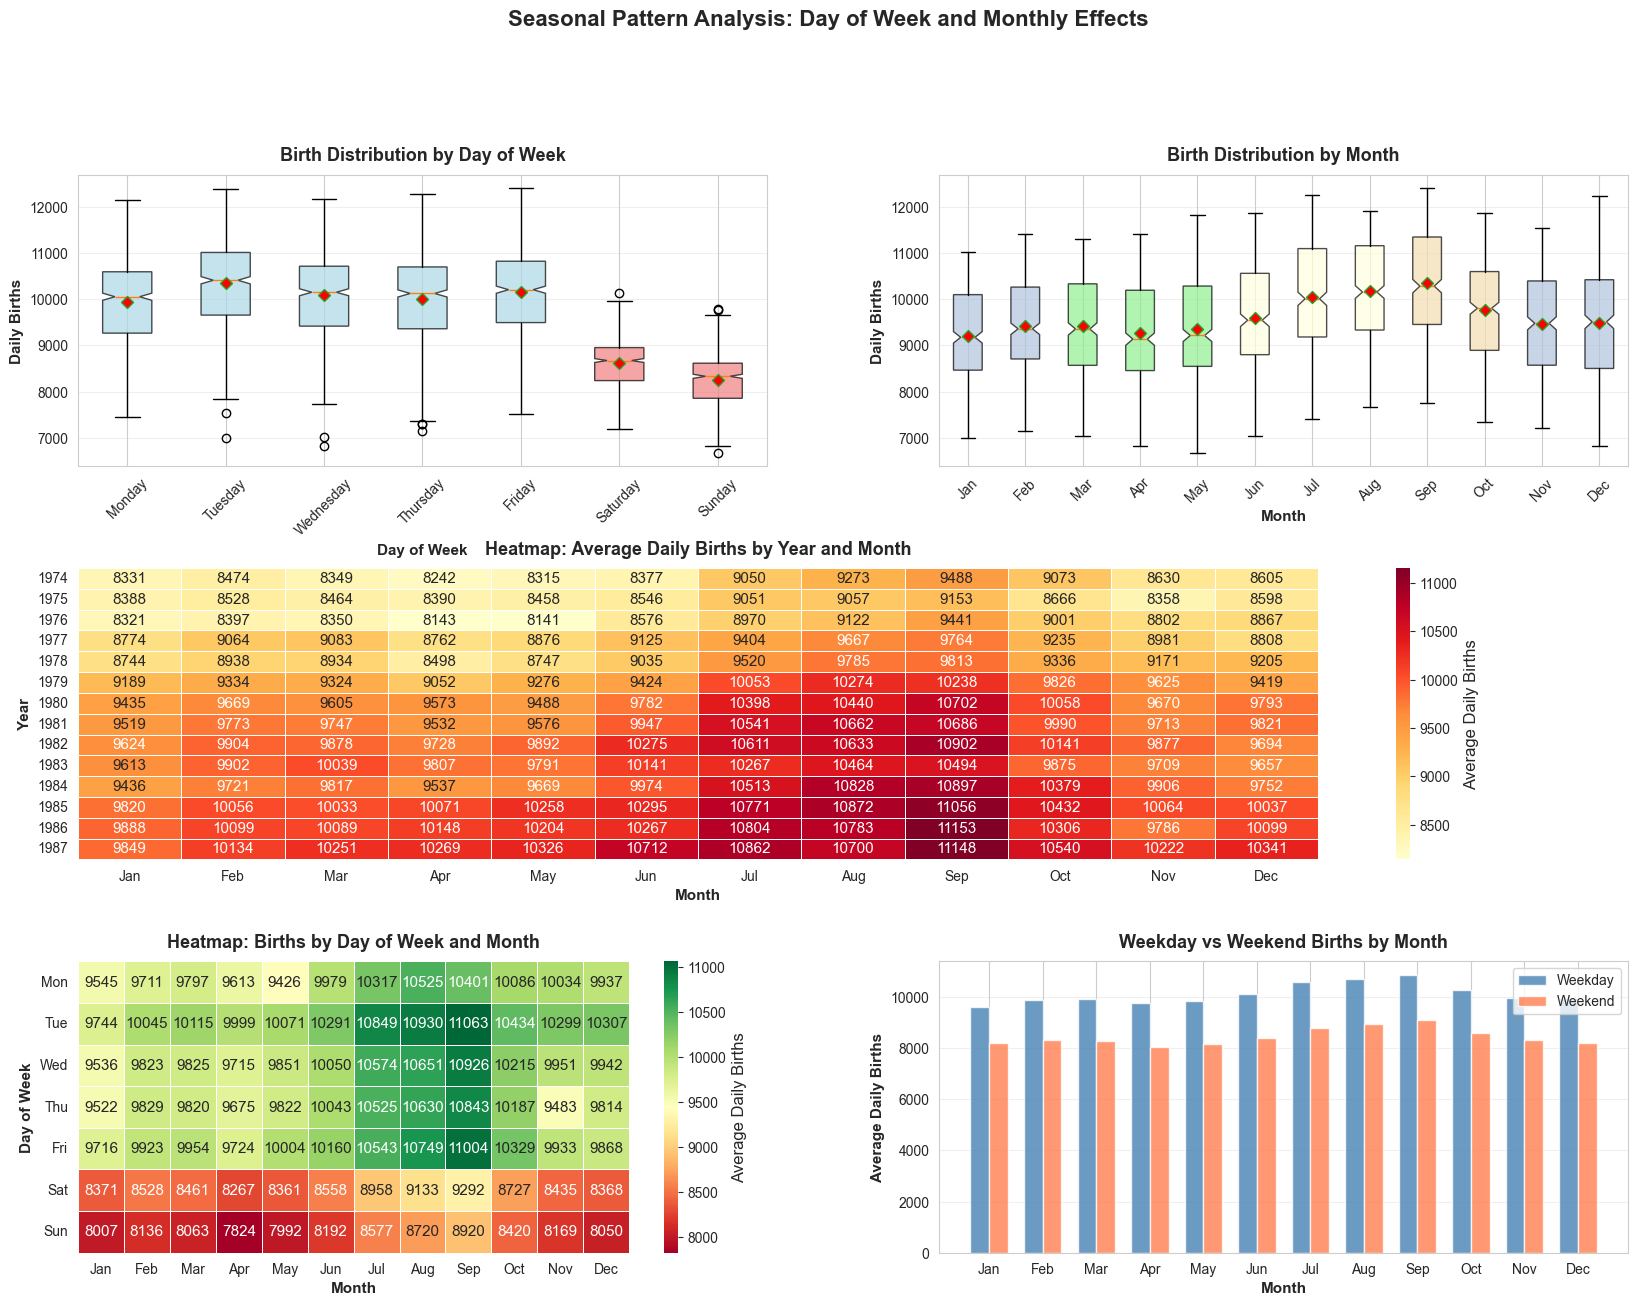


SEASONAL PATTERN SUMMARY

Day of Week Analysis:
                   mean         std     min      max
day_name                                            
Monday      9949.768493  894.974584  7460.0  12156.0
Tuesday    10347.882353  896.534868  7002.0  12396.0
Wednesday  10089.465116  882.106161  6820.0  12178.0
Thursday   10017.124487  939.420247  7145.0  12281.0
Friday     10160.345205  896.157280  7521.0  12412.0
Saturday    8621.465753  560.238541  7185.0  10144.0
Sunday      8257.067123  584.042320  6675.0   9798.0

Weekday average: 10112.95
Weekend average: 8439.27
Difference: 1673.68 (19.8% higher on weekdays)

Monthly Analysis:
                    mean          std     min      max
month_name                                            
January      9209.433180   943.193071  7002.0  11016.0
February     9426.908861   958.179620  7150.0  11412.0
March        9425.921659  1027.633200  7034.0  11317.0
April        9267.980952  1080.457538  6817.0  11417.0
May          9358.336406  

In [9]:
print("="*80)
print("STEP 6: SEASONAL PATTERN ANALYSIS")
print("="*80)

# Create comprehensive seasonal visualizations
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)

# 1. Box plot by day of week
ax1 = fig.add_subplot(gs[0, 0])
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
train_df_sorted = train_df.copy()
train_df_sorted['day_name'] = pd.Categorical(train_df_sorted['day_name'], categories=day_order, ordered=True)

box_plot = ax1.boxplot(
    [train_df_sorted[train_df_sorted['day_name'] == day]['births'].values for day in day_order],
    labels=day_order,
    patch_artist=True,
    notch=True,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='red', markersize=6)
)

# Color weekdays vs weekends differently
colors = ['lightblue']*5 + ['lightcoral']*2
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_xlabel('Day of Week', fontsize=11, fontweight='bold')
ax1.set_ylabel('Daily Births', fontsize=11, fontweight='bold')
ax1.set_title('Birth Distribution by Day of Week', fontsize=13, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# 2. Box plot by month
ax2 = fig.add_subplot(gs[0, 1])
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
train_df_sorted['month_name'] = pd.Categorical(train_df_sorted['month_name'], categories=month_order, ordered=True)

box_plot2 = ax2.boxplot(
    [train_df_sorted[train_df_sorted['month_name'] == month]['births'].values for month in month_order],
    labels=[m[:3] for m in month_order],
    patch_artist=True,
    notch=True,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='red', markersize=6)
)

# Color by season
season_colors = ['lightsteelblue', 'lightsteelblue', 'lightgreen', 'lightgreen', 'lightgreen',
                'lightyellow', 'lightyellow', 'lightyellow', 'wheat', 'wheat', 'lightsteelblue', 'lightsteelblue']
for patch, color in zip(box_plot2['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Month', fontsize=11, fontweight='bold')
ax2.set_ylabel('Daily Births', fontsize=11, fontweight='bold')
ax2.set_title('Birth Distribution by Month', fontsize=13, fontweight='bold', pad=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

# 3. Heatmap: Births by Year and Month
ax3 = fig.add_subplot(gs[1, :])
pivot_table = train_df.pivot_table(values='births', index='year', columns='month', aggfunc='mean')
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax3,
            cbar_kws={'label': 'Average Daily Births'}, linewidths=0.5)
ax3.set_xlabel('Month', fontsize=11, fontweight='bold')
ax3.set_ylabel('Year', fontsize=11, fontweight='bold')
ax3.set_title('Heatmap: Average Daily Births by Year and Month', fontsize=13, fontweight='bold', pad=10)
ax3.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# 4. Heatmap: Births by Day of Week and Month
ax4 = fig.add_subplot(gs[2, 0])
pivot_dow_month = train_df.pivot_table(values='births', index='day_of_week', columns='month', aggfunc='mean')
sns.heatmap(pivot_dow_month, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax4,
            cbar_kws={'label': 'Average Daily Births'}, linewidths=0.5)
ax4.set_xlabel('Month', fontsize=11, fontweight='bold')
ax4.set_ylabel('Day of Week', fontsize=11, fontweight='bold')
ax4.set_title('Heatmap: Births by Day of Week and Month', fontsize=13, fontweight='bold', pad=10)
ax4.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# 5. Average births: Weekday vs Weekend by month
ax5 = fig.add_subplot(gs[2, 1])
weekday_month = train_df[train_df['is_weekend']==0].groupby('month')['births'].mean()
weekend_month = train_df[train_df['is_weekend']==1].groupby('month')['births'].mean()

x = np.arange(1, 13)
width = 0.35
ax5.bar(x - width/2, weekday_month.values, width, label='Weekday', color='steelblue', alpha=0.8)
ax5.bar(x + width/2, weekend_month.values, width, label='Weekend', color='coral', alpha=0.8)
ax5.set_xlabel('Month', fontsize=11, fontweight='bold')
ax5.set_ylabel('Average Daily Births', fontsize=11, fontweight='bold')
ax5.set_title('Weekday vs Weekend Births by Month', fontsize=13, fontweight='bold', pad=10)
ax5.set_xticks(x)
ax5.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3, axis='y')

plt.suptitle('Seasonal Pattern Analysis: Day of Week and Monthly Effects',
             fontsize=16, fontweight='bold', y=0.998)
plt.show()

# Print statistical summary
print("\n" + "="*80)
print("SEASONAL PATTERN SUMMARY")
print("="*80)

print("\nDay of Week Analysis:")
dow_stats = train_df.groupby('day_name')['births'].agg(['mean', 'std', 'min', 'max'])
dow_stats = dow_stats.reindex(day_order)
print(dow_stats)

weekday_avg = train_df[train_df['is_weekend']==0]['births'].mean()
weekend_avg = train_df[train_df['is_weekend']==1]['births'].mean()
print(f"\nWeekday average: {weekday_avg:.2f}")
print(f"Weekend average: {weekend_avg:.2f}")
print(f"Difference: {weekday_avg - weekend_avg:.2f} ({(weekday_avg - weekend_avg)/weekend_avg*100:.1f}% higher on weekdays)")

print("\nMonthly Analysis:")
month_stats = train_df.groupby('month_name')['births'].agg(['mean', 'std', 'min', 'max'])
month_stats = month_stats.reindex(month_order)
print(month_stats)

print("\n✓ Seasonal pattern analysis complete")

---
## Step 7: Fourier and Wavelet Analysis

### Fourier Analysis
Identifies dominant frequencies (periodicities) in the data using Fast Fourier Transform (FFT).

### Wavelet Analysis
Provides time-frequency decomposition to see how periodicities change over time.

STEP 7: FOURIER AND WAVELET ANALYSIS

Computing Fourier Transform...


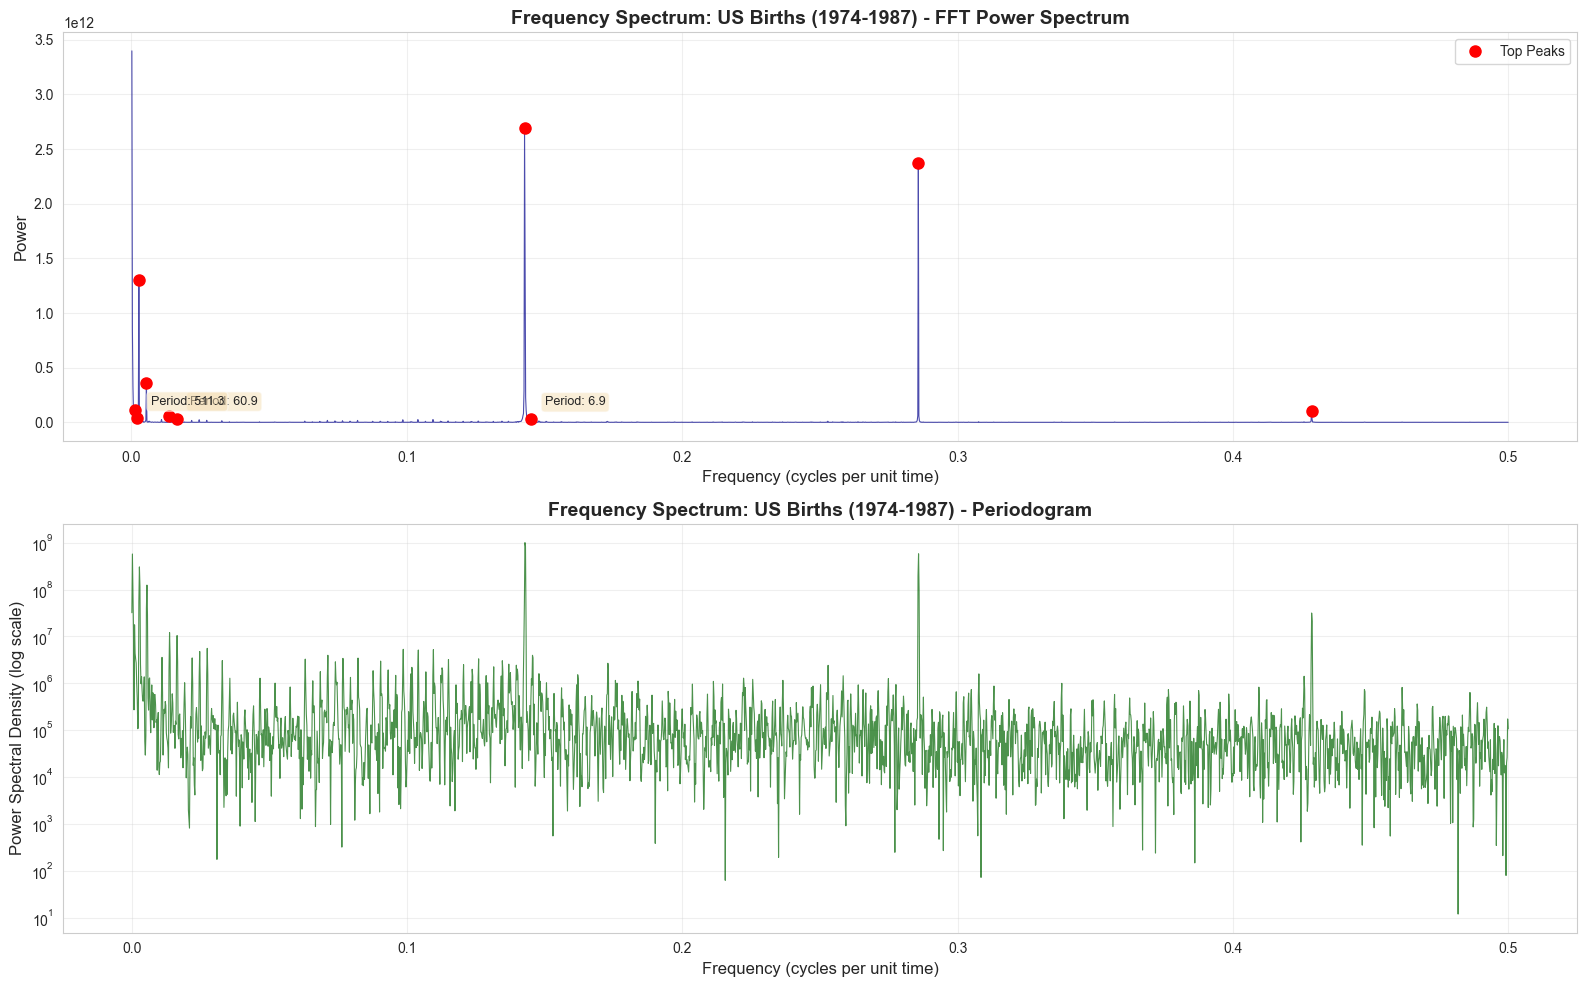


DOMINANT SEASONAL PERIODS
 rank     period  frequency        power interpretation
    1   7.004110   0.142773 2.696240e+12         Weekly
    2   3.499658   0.285742 2.370957e+12       3.5 days
    3 365.214286   0.002738 1.306143e+12         Annual
    4 182.607143   0.005476 3.592350e+11    Semi-annual
    5 730.428571   0.001369 1.096169e+11     730.4 days
    6   2.333638   0.428516 1.005929e+11       2.3 days
    7  73.042857   0.013691 5.990685e+10      73.0 days
    8 511.300000   0.001956 3.501021e+10     511.3 days
    9  60.869048   0.016429 3.477244e+10      60.9 days
   10   6.890836   0.145120 2.906850e+10         Weekly


Identified Seasonal Periods:
   rank      period  frequency         power interpretation
0     1    7.004110   0.142773  2.696240e+12         Weekly
1     2    3.499658   0.285742  2.370957e+12       3.5 days
2     3  365.214286   0.002738  1.306143e+12         Annual
3     4  182.607143   0.005476  3.592350e+11    Semi-annual
4     5  730.428571   0.00

In [10]:
print("="*80)
print("STEP 7: FOURIER AND WAVELET ANALYSIS")
print("="*80)

# Fourier Analysis - Frequency Spectrum
print("\nComputing Fourier Transform...")
fig = spectral.plot_frequency_spectrum(
    train_df['births'].values,
    sampling_rate=1.0,
    title='Frequency Spectrum: US Births (1974-1987)',
    highlight_peaks=True,
    n_peaks=10
)
plt.show()

# Identify seasonal periods
seasonal_periods = spectral.identify_seasonal_periods(
    train_df['births'].values,
    sampling_rate=1.0,
    n_periods=10
)

print("\nIdentified Seasonal Periods:")
print(seasonal_periods)


Computing Power Spectral Density...


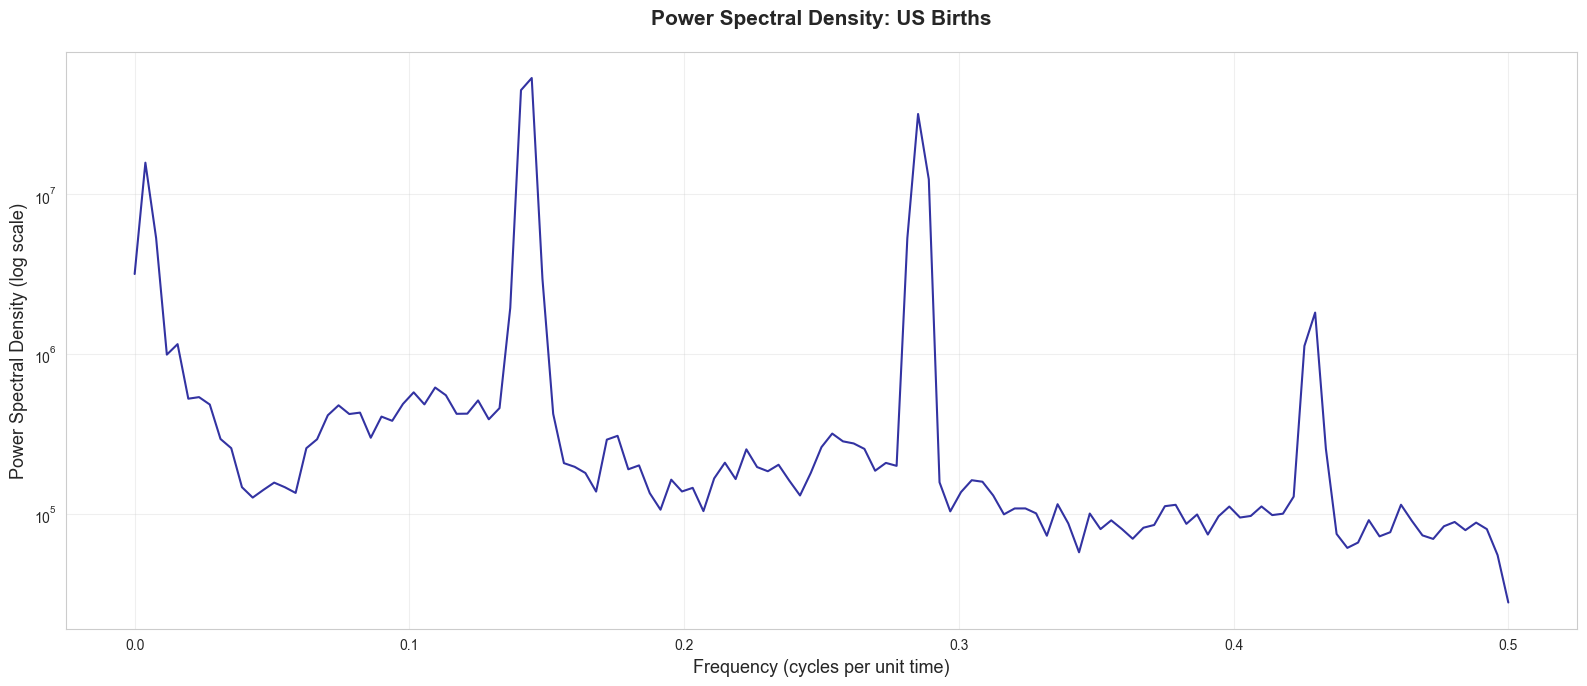

In [11]:
# Power Spectral Density
print("\nComputing Power Spectral Density...")
fig = spectral.plot_psd(
    train_df['births'].values,
    sampling_rate=1.0,
    title='Power Spectral Density: US Births'
)
plt.show()


WAVELET ANALYSIS - TIME-FREQUENCY REPRESENTATION

Computing wavelet transform...
  Scales: 200 (periods: 2.0 to 500.0 days)
  Wavelet: Morlet
✓ Wavelet transform complete


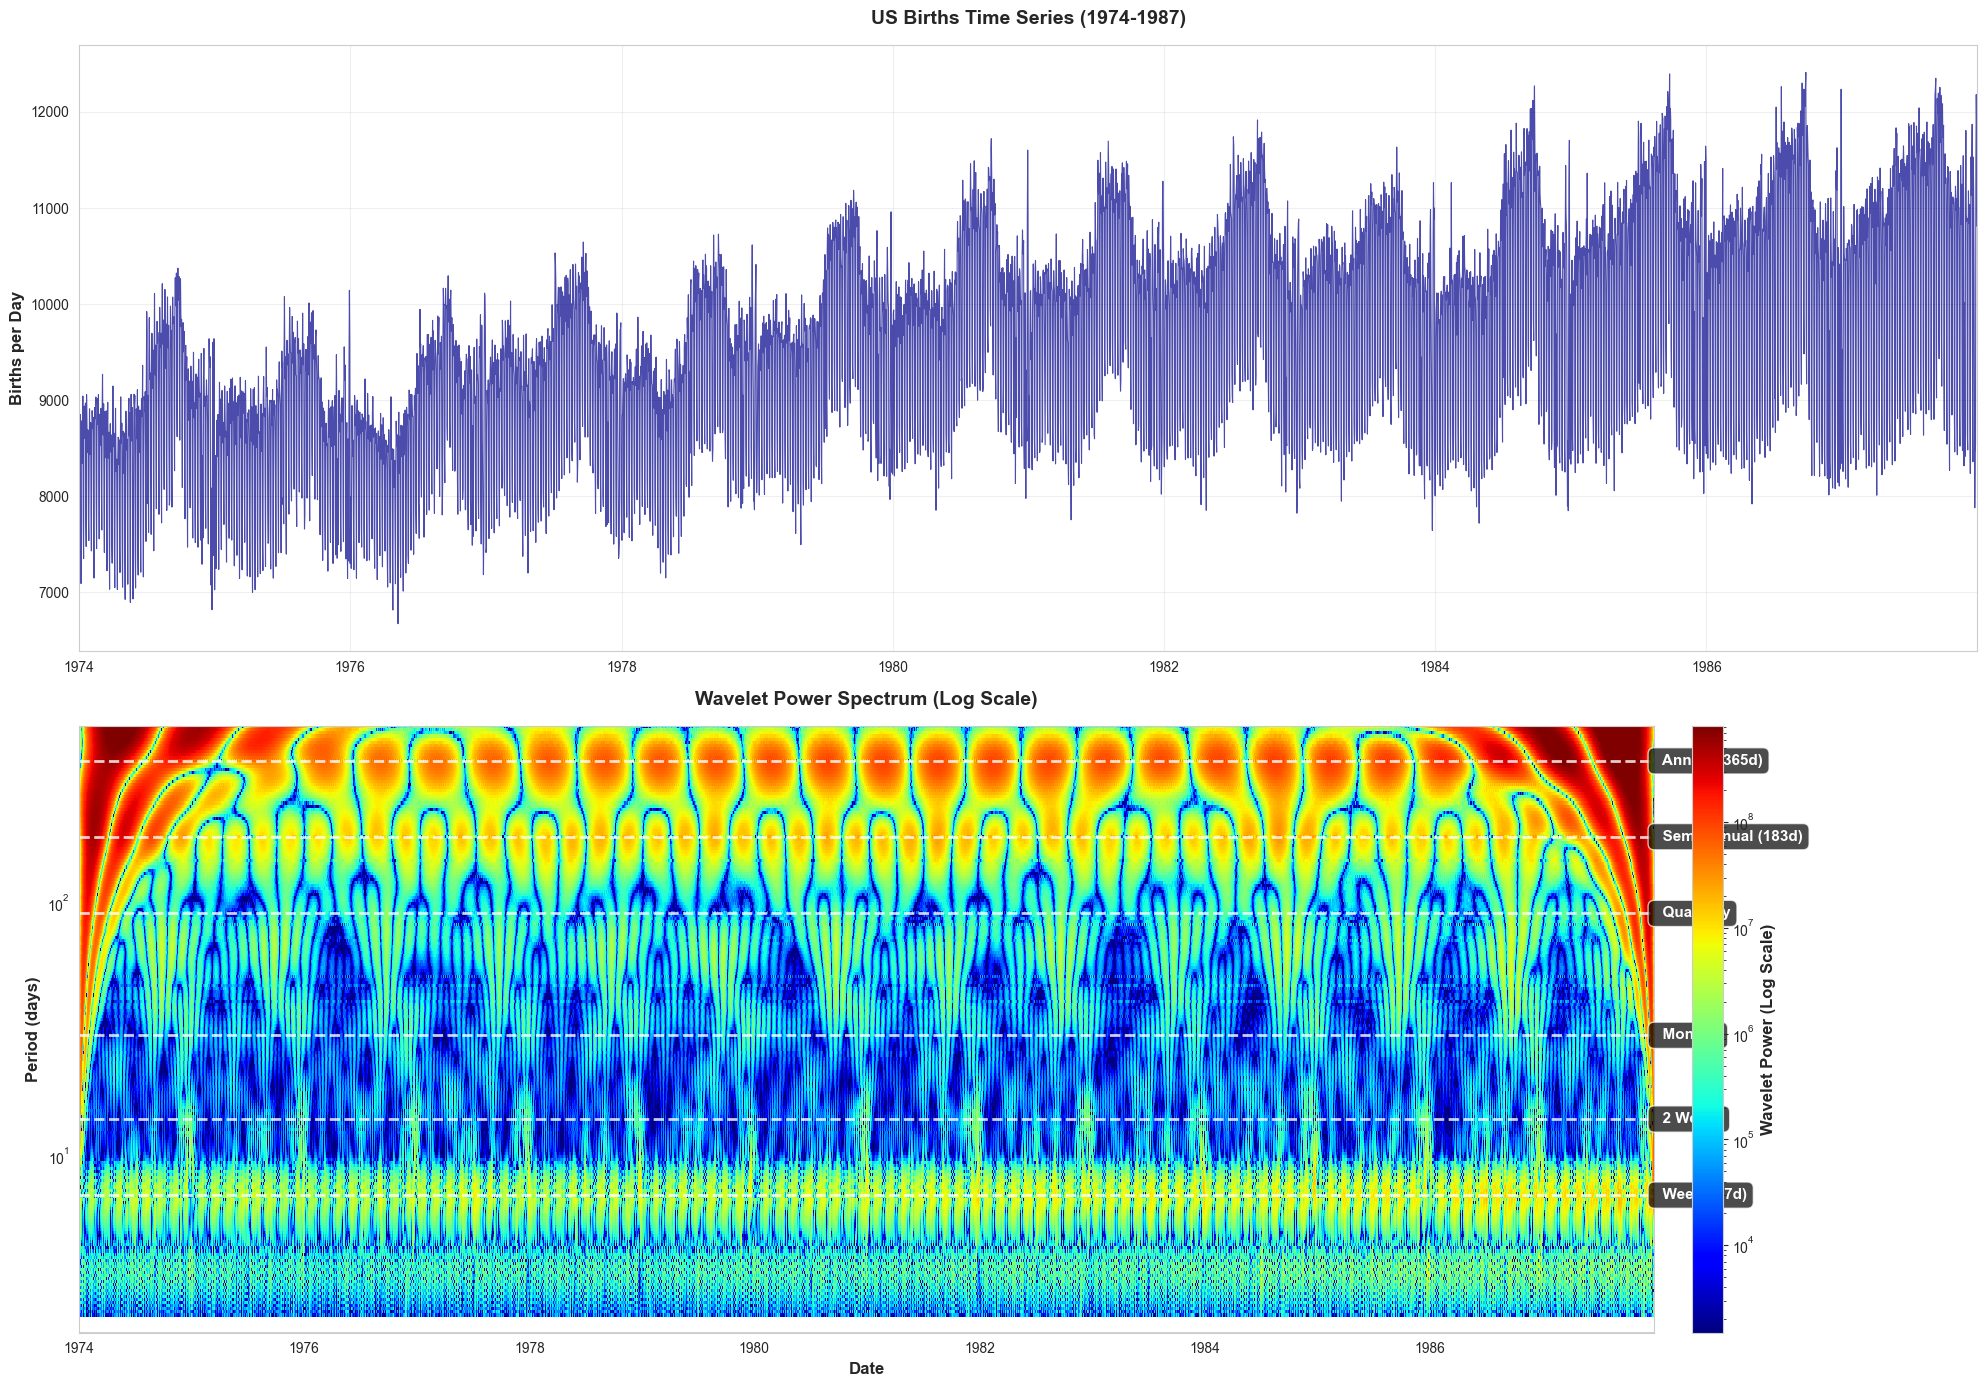


SCALOGRAM INTERPRETATION GUIDE

Color Coding (Log Scale):
  🔴 RED    = Strongest oscillations (high power)
  🟡 YELLOW = Strong oscillations
  🟢 GREEN  = Moderate oscillations
  🔵 BLUE   = Weak oscillations (low power)

What to Look For:
  • HORIZONTAL RED BANDS = Consistent periodic patterns over time
  • VERTICAL RED PATTERNS = Transient events or changes
  • Check the labeled periods:
    - 7 days: Weekly pattern (weekday/weekend effect)
    - 183 days: Semi-annual pattern
    - 365 days: Annual seasonal cycle

Key Observations:
  Average power at 7-day period: 3.61e+06
  Average power at 183-day period: 2.37e+07
  Average power at 365-day period: 1.01e+08


Wavelet Interpretation:
  • Horizontal bright bands indicate consistent periodicities
  • Look for bands at ~7 days (weekly) and ~365 days (annual)
  • Color intensity shows strength of oscillation
  • Log scale reveals patterns across wide range of frequencies


In [13]:
# Continuous Wavelet Transform - Scalogram with Proper Scaling
print("\n" + "="*70)
print("WAVELET ANALYSIS - TIME-FREQUENCY REPRESENTATION")
print("="*70)

import pywt
from matplotlib.colors import LogNorm

# Prepare data
data = train_df['births'].values

# Define scales to cover periods from 2 days to 500 days
# For Morlet wavelet, scale ≈ period / (4*pi) * omega0, where omega0 ≈ 6 for 'morl'
# So for period P, scale ≈ P * 0.477
periods = np.logspace(np.log10(2), np.log10(500), 200)  # 200 scales from 2 to 500 days
scales = periods / (2 * np.pi / 6)  # Convert periods to scales for Morlet wavelet

print(f"\nComputing wavelet transform...")
print(f"  Scales: {len(scales)} (periods: {periods.min():.1f} to {periods.max():.1f} days)")
print(f"  Wavelet: Morlet")

# Compute continuous wavelet transform
coefficients, frequencies = pywt.cwt(data, scales, 'morl', sampling_period=1.0)

# Calculate power (absolute value squared)
power = np.abs(coefficients) ** 2

# Convert frequencies to periods
periods_cwt = 1 / frequencies

print(f"✓ Wavelet transform complete")

# Create figure with better layout
fig, axes = plt.subplots(2, 1, figsize=(20, 14))

# Top plot: Original time series
axes[0].plot(train_df['datetime'], data, linewidth=0.8, color='darkblue', alpha=0.7)
axes[0].set_ylabel('Births per Day', fontsize=12, fontweight='bold')
axes[0].set_title('US Births Time Series (1974-1987)',
                  fontsize=14, fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(train_df['datetime'].iloc[0], train_df['datetime'].iloc[-1])

# Bottom plot: Scalogram with LOG SCALE for power (this is key!)
# Use log normalization to show the full dynamic range
vmin = np.percentile(power[power > 0], 5)   # 5th percentile of non-zero values
vmax = np.percentile(power, 99.5)            # 99.5th percentile

# Plot with pcolormesh for better rendering and LogNorm for colors
im = axes[1].pcolormesh(train_df['datetime'], periods_cwt, power,
                        cmap='jet',
                        norm=LogNorm(vmin=vmin, vmax=vmax),
                        shading='auto')

axes[1].set_ylabel('Period (days)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12, fontweight='bold')
axes[1].set_title('Wavelet Power Spectrum (Log Scale)',
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_yscale('log')
axes[1].set_ylim([2, 500])

# Add gridlines
axes[1].grid(True, alpha=0.4, color='white', linestyle='--', linewidth=0.8)

# Add reference lines for key periods with labels
key_periods = {
    7: 'Weekly (7d)',
    14: '2 Weeks',
    30: 'Monthly',
    91: 'Quarterly',
    183: 'Semi-annual (183d)',
    365: 'Annual (365d)'
}

for period, label in key_periods.items():
    if 2 <= period <= 500:
        axes[1].axhline(y=period, color='white', linestyle='--', linewidth=2, alpha=0.8)
        # Add label on the right side
        axes[1].text(train_df['datetime'].iloc[-1], period, f'  {label}',
                    fontsize=11, color='white', fontweight='bold',
                    verticalalignment='center', horizontalalignment='left',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.7, edgecolor='white'))

# Add colorbar with proper label
cbar = plt.colorbar(im, ax=axes[1], pad=0.02)
cbar.set_label('Wavelet Power (Log Scale)', fontsize=12, fontweight='bold')

# Add cone of influence (optional - shows edge effects)
# Cone of influence for Morlet wavelet is approximately sqrt(2) * scale
coi = periods_cwt * np.sqrt(2)
axes[1].fill_between(train_df['datetime'], 0, 2,
                     color='gray', alpha=0.3, label='Edge effects')

plt.tight_layout()
plt.show()

# Print interpretation guide
print("\n" + "="*70)
print("SCALOGRAM INTERPRETATION GUIDE")
print("="*70)
print("\nColor Coding (Log Scale):")
print("  🔴 RED    = Strongest oscillations (high power)")
print("  🟡 YELLOW = Strong oscillations")
print("  🟢 GREEN  = Moderate oscillations")
print("  🔵 BLUE   = Weak oscillations (low power)")

print("\nWhat to Look For:")
print("  • HORIZONTAL RED BANDS = Consistent periodic patterns over time")
print("  • VERTICAL RED PATTERNS = Transient events or changes")
print("  • Check the labeled periods:")
print(f"    - 7 days: Weekly pattern (weekday/weekend effect)")
print(f"    - 183 days: Semi-annual pattern")
print(f"    - 365 days: Annual seasonal cycle")

print("\nKey Observations:")
# Calculate average power at key periods
idx_7d = np.argmin(np.abs(periods_cwt - 7))
idx_183d = np.argmin(np.abs(periods_cwt - 183))
idx_365d = np.argmin(np.abs(periods_cwt - 365))

avg_power_7d = np.mean(power[idx_7d, :])
avg_power_183d = np.mean(power[idx_183d, :])
avg_power_365d = np.mean(power[idx_365d, :])

print(f"  Average power at 7-day period: {avg_power_7d:.2e}")
print(f"  Average power at 183-day period: {avg_power_183d:.2e}")
print(f"  Average power at 365-day period: {avg_power_365d:.2e}")

print("\n" + "="*70)

print("\nWavelet Interpretation:")
print("  • Horizontal bright bands indicate consistent periodicities")
print("  • Look for bands at ~7 days (weekly) and ~365 days (annual)")
print("  • Color intensity shows strength of oscillation")
print("  • Log scale reveals patterns across wide range of frequencies")


Performing Seasonal Decomposition...


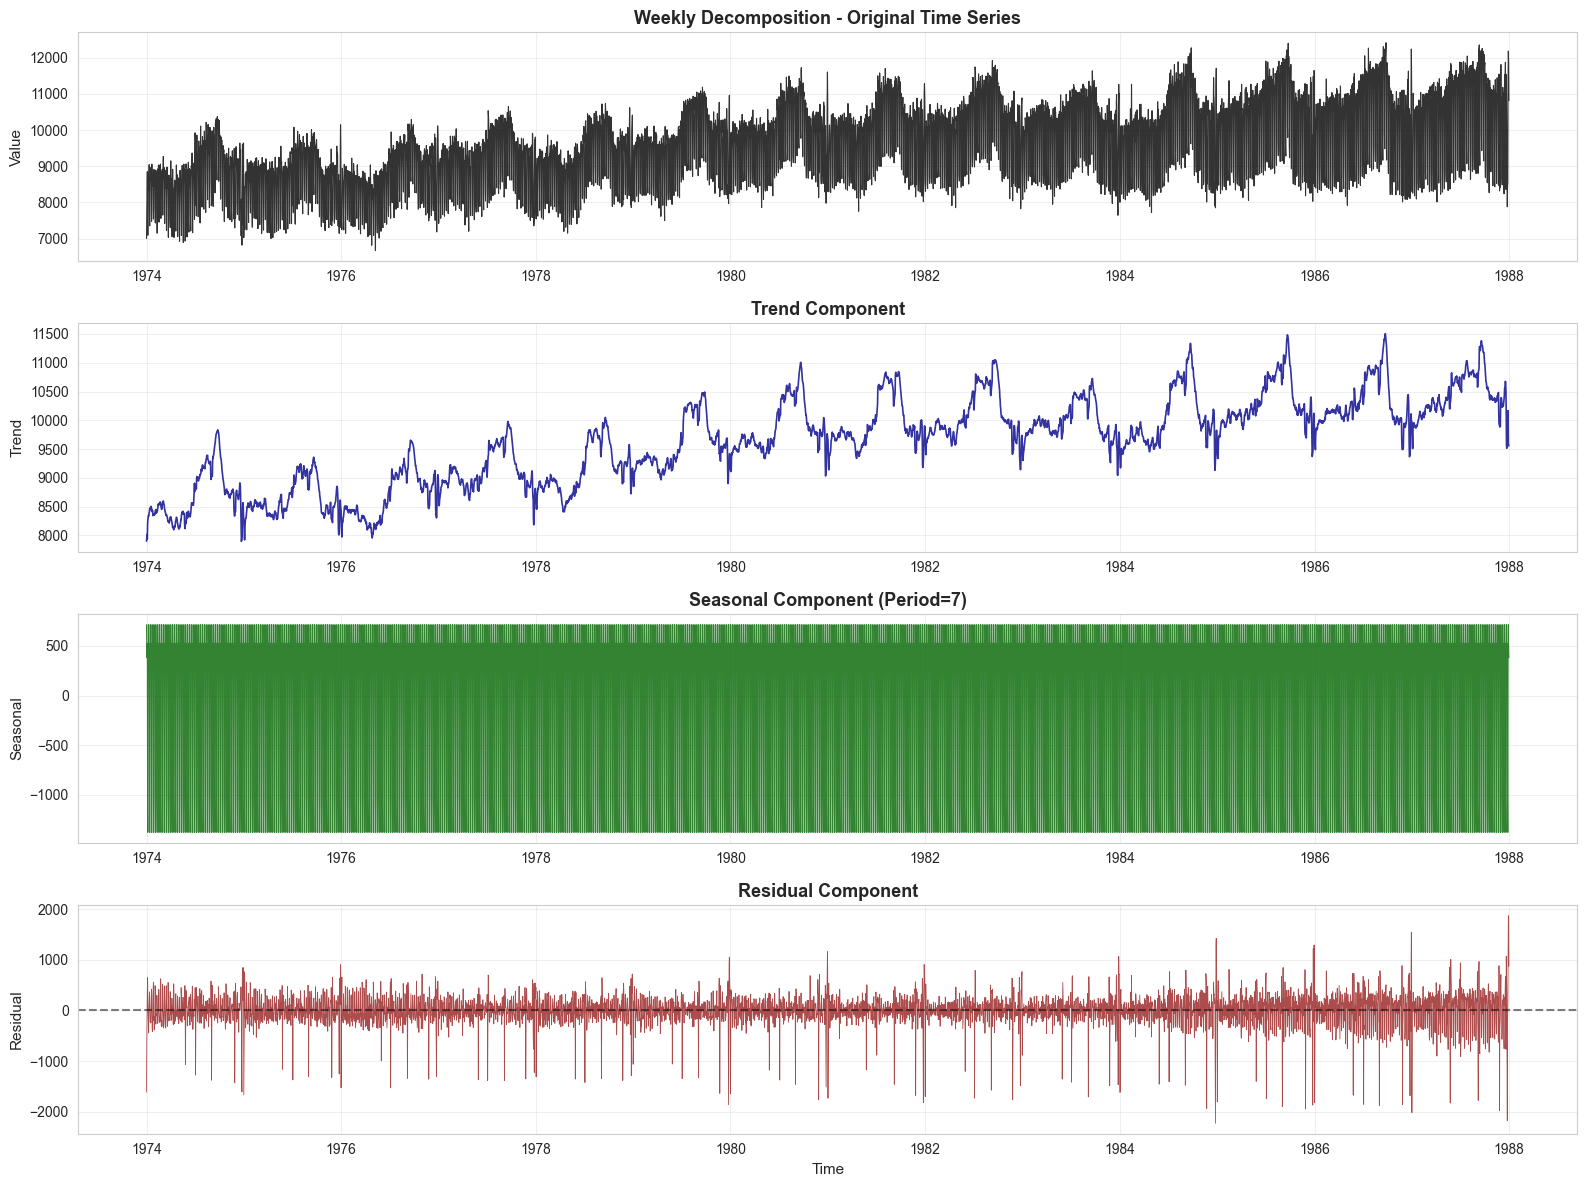


✓ Fourier and wavelet analysis complete

Key Findings:
  • Strong weekly periodicity (~7 days) - weekday/weekend effect
  • Annual periodicity (~365 days) - seasonal birth patterns
  • Semi-annual component (~183 days) - additional seasonal effect


In [14]:
# Seasonal Decomposition
print("\nPerforming Seasonal Decomposition...")
births_series = train_df.set_index('datetime')['births']

# Weekly seasonality
fig = sarima.plot_seasonal_decomposition(
    births_series,
    period=7,
    model='additive',
    title_prefix='Weekly Decomposition - '
)
plt.show()

print("\n✓ Fourier and wavelet analysis complete")
print("\nKey Findings:")
print("  • Strong weekly periodicity (~7 days) - weekday/weekend effect")
print("  • Annual periodicity (~365 days) - seasonal birth patterns")
print("  • Semi-annual component (~183 days) - additional seasonal effect")

---
## Step 8: SARIMA Model Search

Search for the best SARIMA(p,d,q)×(P,D,Q,s) model using grid search.

Based on our analysis:
- Weekly seasonality detected → s=7
- We'll search over moderate parameter ranges to find optimal model

In [15]:
print("="*80)
print("STEP 8: SARIMA MODEL SEARCH")
print("="*80)

print("\nSearching for best SARIMA model with weekly seasonality (s=7)...")
print("This will test multiple parameter combinations.")
print("Estimated time: 5-10 minutes\n")

# SARIMA grid search with weekly seasonality
sarima_results = sarima.sarima_grid_search(
    train_df['births'].values,
    p_range=range(0, 4),      # Non-seasonal AR
    d_range=range(0, 3),      # Non-seasonal differencing
    q_range=range(0, 5),      # Non-seasonal MA
    P_range=range(0, 3),      # Seasonal AR
    D_range=range(0, 2),      # Seasonal differencing
    Q_range=range(0, 3),      # Seasonal MA
    s=7,                      # Weekly seasonality
    verbose=True
)

print("\n" + "="*80)
print("TOP 10 SARIMA MODELS (sorted by AIC)")
print("="*80)
print(sarima_results.head(10).to_string(index=False))

# Extract best model
best_sarima = sarima_results.iloc[0]
best_order = (int(best_sarima['p']), int(best_sarima['d']), int(best_sarima['q']))
best_seasonal = (int(best_sarima['P']), int(best_sarima['D']),
                 int(best_sarima['Q']), int(best_sarima['s']))

print("\n" + "="*80)
print("BEST SARIMA MODEL")
print("="*80)
print(f"Model: SARIMA{best_order} × {best_seasonal}")
print(f"AIC: {best_sarima['AIC']:.2f}")
print(f"BIC: {best_sarima['BIC']:.2f}")
print(f"HQIC: {best_sarima['HQIC']:.2f}")
print("="*80)

STEP 8: SARIMA MODEL SEARCH

Searching for best SARIMA model with weekly seasonality (s=7)...
This will test multiple parameter combinations.
Estimated time: 5-10 minutes

Testing 1080 SARIMA models...
Seasonal period: 7
Progress: 20/1080 models tested...
Progress: 40/1080 models tested...
Progress: 60/1080 models tested...
Progress: 80/1080 models tested...
Progress: 100/1080 models tested...
Progress: 120/1080 models tested...
Progress: 140/1080 models tested...
Progress: 160/1080 models tested...
Progress: 180/1080 models tested...
Progress: 200/1080 models tested...
Progress: 220/1080 models tested...
Progress: 240/1080 models tested...
Progress: 260/1080 models tested...
Progress: 280/1080 models tested...
Progress: 300/1080 models tested...
Progress: 320/1080 models tested...
Progress: 340/1080 models tested...
Progress: 360/1080 models tested...
Progress: 380/1080 models tested...
Progress: 400/1080 models tested...
Progress: 420/1080 models tested...
Progress: 440/1080 models t

In [16]:
# Fit the best SARIMA model
print(f"\nFitting best SARIMA model: SARIMA{best_order} × {best_seasonal}...")

best_sarima_fitted = sarima.fit_sarima_model(
    train_df['births'].values,
    order=best_order,
    seasonal_order=best_seasonal,
    verbose=True
)


Fitting best SARIMA model: SARIMA(2, 1, 4) × (2, 1, 2, 7)...

SARIMA(2, 1, 4)x(2, 1, 2, 7) Model Summary
                                       SARIMAX Results                                        
Dep. Variable:                                      y   No. Observations:                 5113
Model:             SARIMAX(2, 1, 4)x(2, 1, [1, 2], 7)   Log Likelihood              -36482.825
Date:                                Fri, 05 Dec 2025   AIC                          72987.650
Time:                                        10:57:26   BIC                          73059.526
Sample:                                             0   HQIC                         73012.819
                                               - 5113                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------


Model Diagnostics...


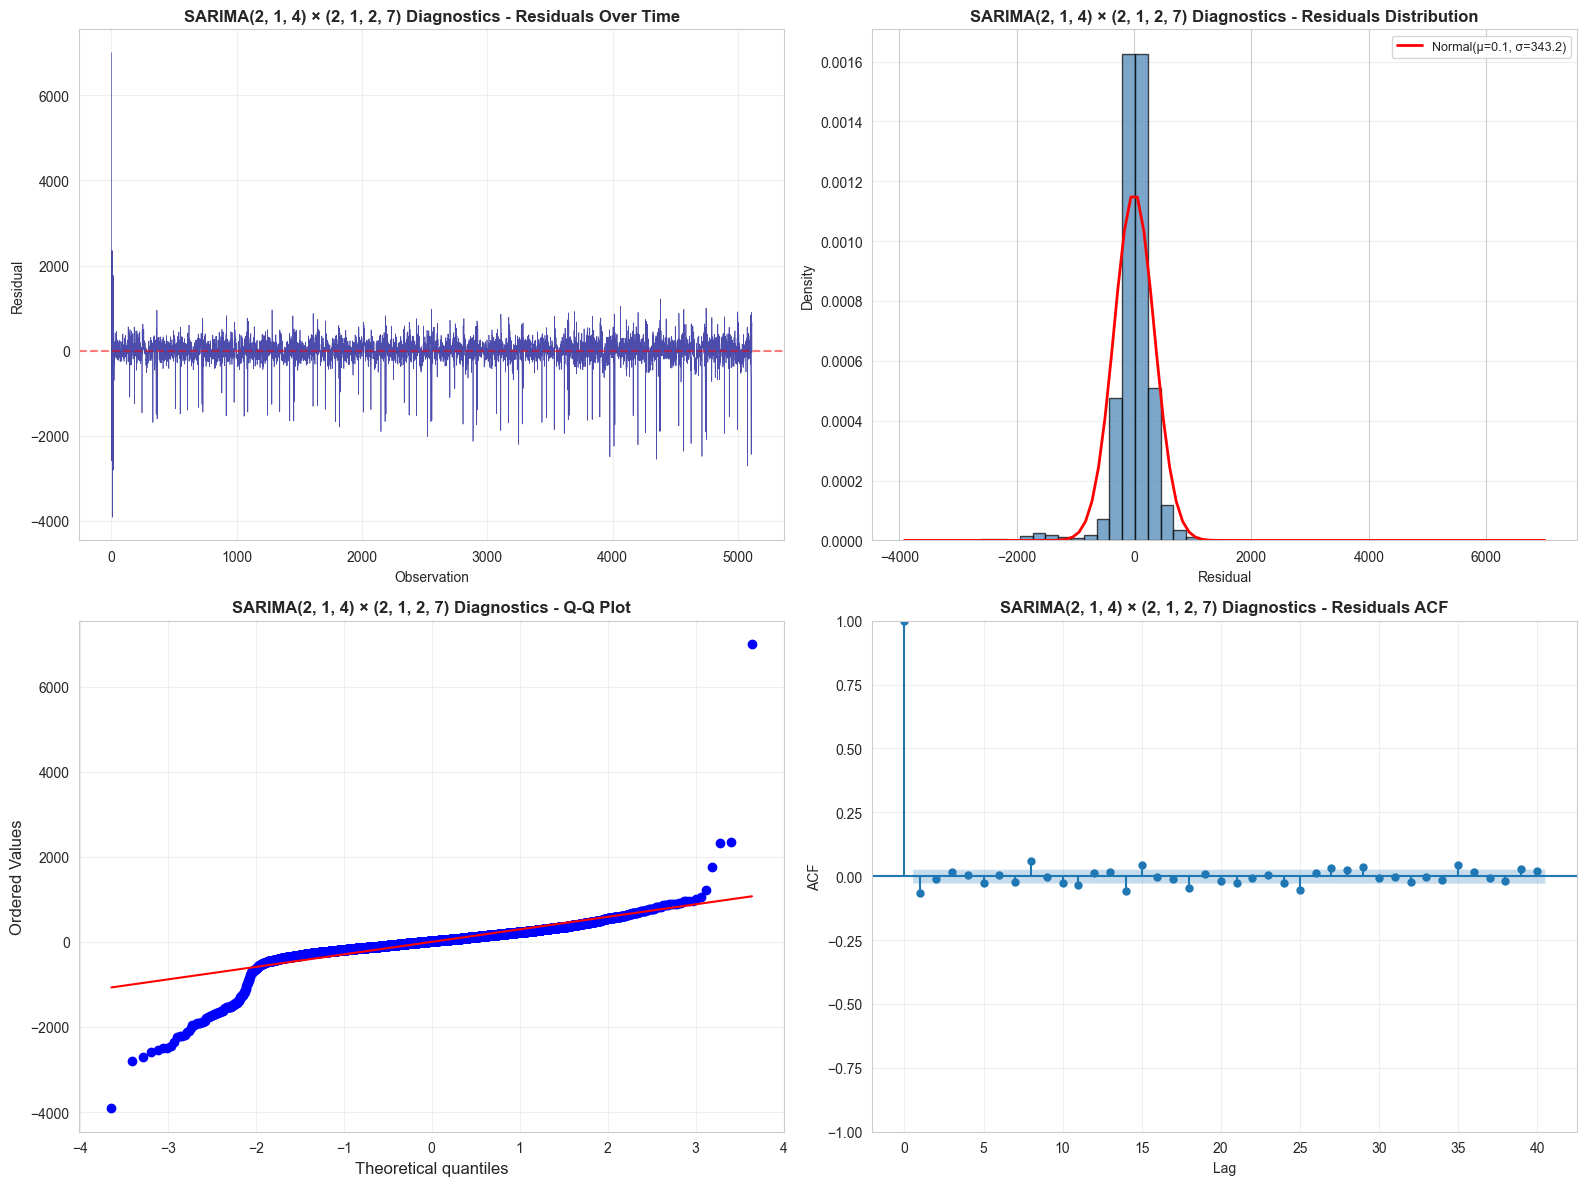


SARIMA RESIDUAL DIAGNOSTICS

Residual Statistics:
  Mean: 0.055901 (should be close to 0)
  Std Dev: 343.23
  Min: -3913.75
  Max: 7002.00

Ljung-Box Test (tests for residual autocorrelation):
       lb_stat     lb_pvalue
10   50.060895  2.601133e-07
20   97.358170  3.729963e-12
30  138.178619  7.992209e-16

  → If p-values > 0.05, residuals are white noise (good!)

✓ SARIMA model search complete


In [17]:
# Model diagnostics
print("\nModel Diagnostics...")
fig = sarima.plot_sarima_diagnostics(
    best_sarima_fitted,
    title=f"SARIMA{best_order} × {best_seasonal} Diagnostics"
)
plt.show()

sarima.print_sarima_diagnostics(best_sarima_fitted)

print("\n✓ SARIMA model search complete")

---
## Step 9: Add Fourier Terms for Multiple Seasonality

Our analysis revealed multiple seasonal patterns:
- **Weekly** (7 days): Captured by SARIMA seasonal component
- **Semi-annual** (~183 days): Will use Fourier terms
- **Annual** (~365 days): Will use Fourier terms

We'll create a SARIMAX model that combines:
- SARIMA(p,d,q)×(P,D,Q,7) for weekly seasonality
- Fourier terms as exogenous variables for longer-period seasonality

In [18]:
print("="*80)
print("STEP 9: SARIMAX WITH FOURIER TERMS FOR MULTIPLE SEASONALITY")
print("="*80)

def create_fourier_terms(dates, period, n_harmonics):
    """
    Create Fourier terms for seasonal modeling

    Parameters:
    -----------
    dates : array-like
        Date index
    period : int
        Seasonal period in days (e.g., 365 for annual, 183 for semi-annual)
    n_harmonics : int
        Number of Fourier harmonic pairs (sin/cos)

    Returns:
    --------
    DataFrame with Fourier terms
    """
    fourier_terms = {}
    t = np.arange(len(dates))

    for k in range(1, n_harmonics + 1):
        fourier_terms[f'sin_{period}_{k}'] = np.sin(2 * np.pi * k * t / period)
        fourier_terms[f'cos_{period}_{k}'] = np.cos(2 * np.pi * k * t / period)

    return pd.DataFrame(fourier_terms)

# Generate Fourier terms for training data
print("\nGenerating Fourier terms...")
print("  Strategy:")
print("    1. Weekly (7-day): SARIMA seasonal component")
print("    2. Annual (365-day): 2 Fourier harmonics")
print("    3. Semi-annual (183-day): 2 Fourier harmonics")

# Number of harmonics
n_harmonics_annual = 2
n_harmonics_semi = 2

# Annual seasonality (365 days)
fourier_train_annual = create_fourier_terms(
    train_df['datetime'],
    period=365,
    n_harmonics=n_harmonics_annual
)

# Semi-annual seasonality (183 days)
fourier_train_semi = create_fourier_terms(
    train_df['datetime'],
    period=183,
    n_harmonics=n_harmonics_semi
)

# Combine Fourier terms
fourier_train = pd.concat([
    fourier_train_annual,
    fourier_train_semi
], axis=1)

print(f"\n✓ Training Fourier terms: {fourier_train.shape[1]} features")
print(f"    • Annual (365 days): {n_harmonics_annual} harmonics = {n_harmonics_annual*2} terms")
print(f"    • Semi-annual (183 days): {n_harmonics_semi} harmonics = {n_harmonics_semi*2} terms")

# Generate Fourier terms for test data
fourier_test_annual = create_fourier_terms(
    test_df['datetime'],
    period=365,
    n_harmonics=n_harmonics_annual
)

fourier_test_semi = create_fourier_terms(
    test_df['datetime'],
    period=183,
    n_harmonics=n_harmonics_semi
)

# Combine test Fourier terms
fourier_test = pd.concat([
    fourier_test_annual,
    fourier_test_semi
], axis=1)

print(f"✓ Test Fourier terms: {fourier_test.shape[1]} features")

print("\nFourier terms preview:")
print(fourier_train.head())

STEP 9: SARIMAX WITH FOURIER TERMS FOR MULTIPLE SEASONALITY

Generating Fourier terms...
  Strategy:
    1. Weekly (7-day): SARIMA seasonal component
    2. Annual (365-day): 2 Fourier harmonics
    3. Semi-annual (183-day): 2 Fourier harmonics

✓ Training Fourier terms: 8 features
    • Annual (365 days): 2 harmonics = 4 terms
    • Semi-annual (183 days): 2 harmonics = 4 terms
✓ Test Fourier terms: 8 features

Fourier terms preview:
   sin_365_1  cos_365_1  sin_365_2  cos_365_2  sin_183_1  cos_183_1  \
0   0.000000   1.000000   0.000000   1.000000   0.000000   1.000000   
1   0.017213   0.999852   0.034422   0.999407   0.034328   0.999411   
2   0.034422   0.999407   0.068802   0.997630   0.068615   0.997643   
3   0.051620   0.998667   0.103102   0.994671   0.102821   0.994700   
4   0.068802   0.997630   0.137279   0.990532   0.136906   0.990584   

   sin_183_2  cos_183_2  
0   0.000000   1.000000  
1   0.068615   0.997643  
2   0.136906   0.990584  
3   0.204552   0.978856  
4   

In [19]:
# Fit SARIMAX model with Fourier terms
print("\n" + "="*80)
print("FITTING SARIMAX MODEL WITH FOURIER EXOGENOUS VARIABLES")
print("="*80)

print(f"\nModel Specification:")
print(f"  • SARIMA order: {best_order}")
print(f"  • Seasonal order: {best_seasonal}")
print(f"  • Exogenous variables: {fourier_train.shape[1]} Fourier terms")

print(f"\nFitting model...")

# Fit SARIMAX with Fourier terms
sarimax_model = SARIMAX(
    train_df['births'].values,
    order=best_order,
    seasonal_order=best_seasonal,
    exog=fourier_train,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fitted = sarimax_model.fit(disp=False, maxiter=200)

print("\n" + "="*80)
print(f"SARIMAX{best_order} × {best_seasonal} MODEL SUMMARY")
print("With Fourier Exogenous Variables")
print("="*80)
print(sarimax_fitted.summary())


FITTING SARIMAX MODEL WITH FOURIER EXOGENOUS VARIABLES

Model Specification:
  • SARIMA order: (2, 1, 4)
  • Seasonal order: (2, 1, 2, 7)
  • Exogenous variables: 8 Fourier terms

Fitting model...

SARIMAX(2, 1, 4) × (2, 1, 2, 7) MODEL SUMMARY
With Fourier Exogenous Variables
                                       SARIMAX Results                                        
Dep. Variable:                                      y   No. Observations:                 5113
Model:             SARIMAX(2, 1, 4)x(2, 1, [1, 2], 7)   Log Likelihood              -36489.201
Date:                                Fri, 05 Dec 2025   AIC                          73016.403
Time:                                        11:01:17   BIC                          73140.554
Sample:                                             0   HQIC                         73059.878
                                               - 5113                                         
Covariance Type:                                  opg    


SARIMAX Model Diagnostics...


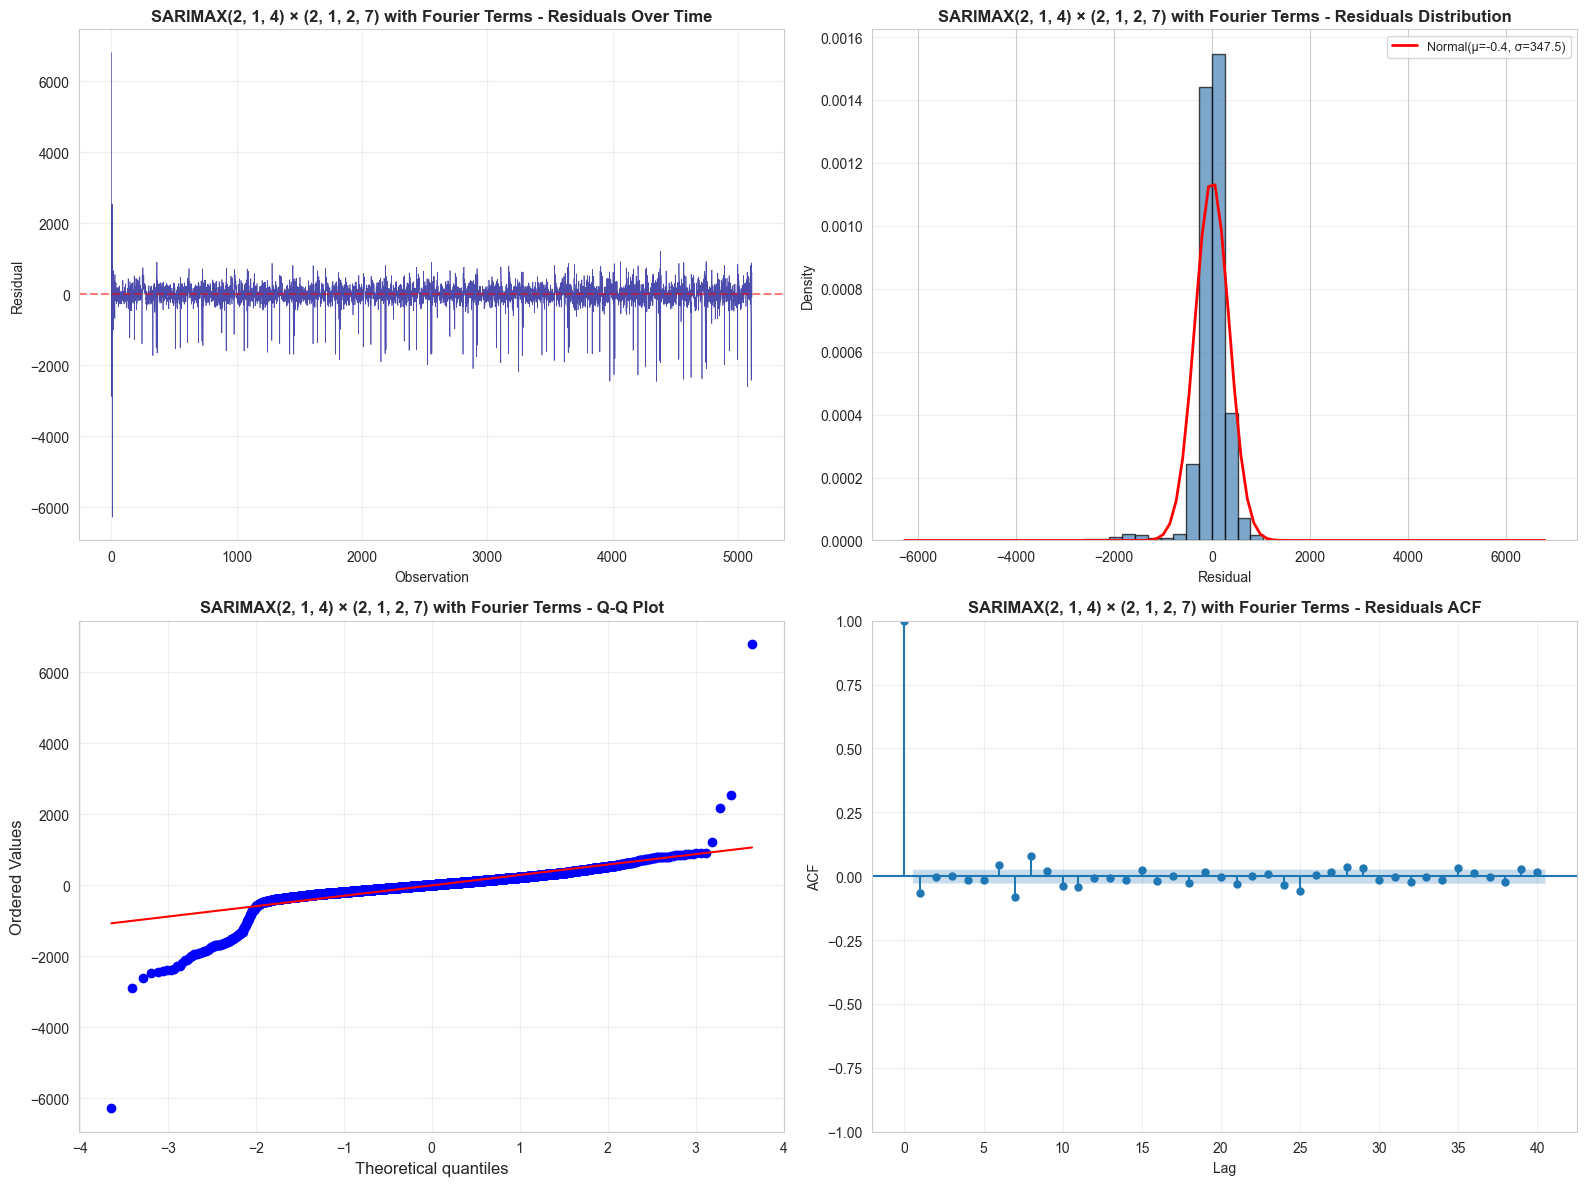


MODEL COMPARISON

SARIMA (weekly seasonality only):
  AIC: 72987.65
  BIC: 73059.53

SARIMAX (weekly + Fourier for annual/semi-annual):
  AIC: 73016.40
  BIC: 73140.55

✗ SARIMA without Fourier terms has lower AIC

✓ SARIMAX model with Fourier terms fitted successfully


In [20]:
# Model diagnostics
print("\nSARIMAX Model Diagnostics...")
fig = sarima.plot_sarima_diagnostics(
    sarimax_fitted,
    title=f"SARIMAX{best_order} × {best_seasonal} with Fourier Terms"
)
plt.show()

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(f"\nSARIMA (weekly seasonality only):")
print(f"  AIC: {best_sarima_fitted.aic:.2f}")
print(f"  BIC: {best_sarima_fitted.bic:.2f}")

print(f"\nSARIMAX (weekly + Fourier for annual/semi-annual):")
print(f"  AIC: {sarimax_fitted.aic:.2f}")
print(f"  BIC: {sarimax_fitted.bic:.2f}")

if sarimax_fitted.aic < best_sarima_fitted.aic:
    print(f"\n✓ SARIMAX with Fourier terms provides better fit (lower AIC)")
else:
    print(f"\n✗ SARIMA without Fourier terms has lower AIC")

print("\n✓ SARIMAX model with Fourier terms fitted successfully")

---
## Step 10: Model Validation on Test Data

Evaluate both models on the 1988 test set:
1. SARIMA (weekly seasonality only)
2. SARIMAX (weekly + Fourier terms for annual/semi-annual)

In [21]:
print("="*80)
print("STEP 10: MODEL VALIDATION ON TEST DATA")
print("="*80)

# Generate forecasts
forecast_steps = len(test_df)

print(f"\nGenerating forecasts for {forecast_steps} days (year 1988)...\n")

# 1. SARIMA forecast (no exogenous variables)
print("1. SARIMA forecast (weekly seasonality only)...")
sarima_forecast = best_sarima_fitted.forecast(steps=forecast_steps)
sarima_forecast_df = best_sarima_fitted.get_forecast(steps=forecast_steps)
sarima_conf_int = sarima_forecast_df.conf_int()

# 2. SARIMAX forecast (with Fourier exogenous variables)
print("2. SARIMAX forecast (weekly + Fourier for annual/semi-annual)...")
sarimax_forecast = sarimax_fitted.forecast(steps=forecast_steps, exog=fourier_test)
sarimax_forecast_df = sarimax_fitted.get_forecast(steps=forecast_steps, exog=fourier_test)
sarimax_conf_int = sarimax_forecast_df.conf_int()

# Actual test values
test_actual = test_df['births'].values

# Calculate errors
def calculate_metrics(actual, predicted, model_name):
    errors = actual - predicted
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    mape = np.mean(np.abs(errors / actual)) * 100

    print(f"\n{model_name}:")
    print(f"  MAE:  {mae:.2f} births/day")
    print(f"  RMSE: {rmse:.2f} births/day")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print("\n" + "="*80)
print("FORECAST ACCURACY METRICS")
print("="*80)

sarima_metrics = calculate_metrics(test_actual, sarima_forecast, "SARIMA (weekly only)")
sarimax_metrics = calculate_metrics(test_actual, sarimax_forecast, "SARIMAX (weekly + Fourier)")

print("\n" + "="*80)
print("MODEL COMPARISON ON TEST SET")
print("="*80)

if sarimax_metrics['RMSE'] < sarima_metrics['RMSE']:
    improvement = (sarima_metrics['RMSE'] - sarimax_metrics['RMSE']) / sarima_metrics['RMSE'] * 100
    print(f"\n✓ SARIMAX with Fourier terms performs better")
    print(f"  RMSE improvement: {improvement:.2f}%")
    best_forecast = sarimax_forecast
    best_model_name = "SARIMAX (with Fourier)"
else:
    improvement = (sarimax_metrics['RMSE'] - sarima_metrics['RMSE']) / sarimax_metrics['RMSE'] * 100
    print(f"\n✓ SARIMA (weekly only) performs better")
    print(f"  RMSE difference: {improvement:.2f}%")
    best_forecast = sarima_forecast
    best_model_name = "SARIMA"

STEP 10: MODEL VALIDATION ON TEST DATA

Generating forecasts for 366 days (year 1988)...

1. SARIMA forecast (weekly seasonality only)...
2. SARIMAX forecast (weekly + Fourier for annual/semi-annual)...

FORECAST ACCURACY METRICS

SARIMA (weekly only):
  MAE:  948.99 births/day
  RMSE: 1118.33 births/day
  MAPE: 8.70%

SARIMAX (weekly + Fourier):
  MAE:  686.97 births/day
  RMSE: 860.03 births/day
  MAPE: 6.71%

MODEL COMPARISON ON TEST SET

✓ SARIMAX with Fourier terms performs better
  RMSE improvement: 23.10%


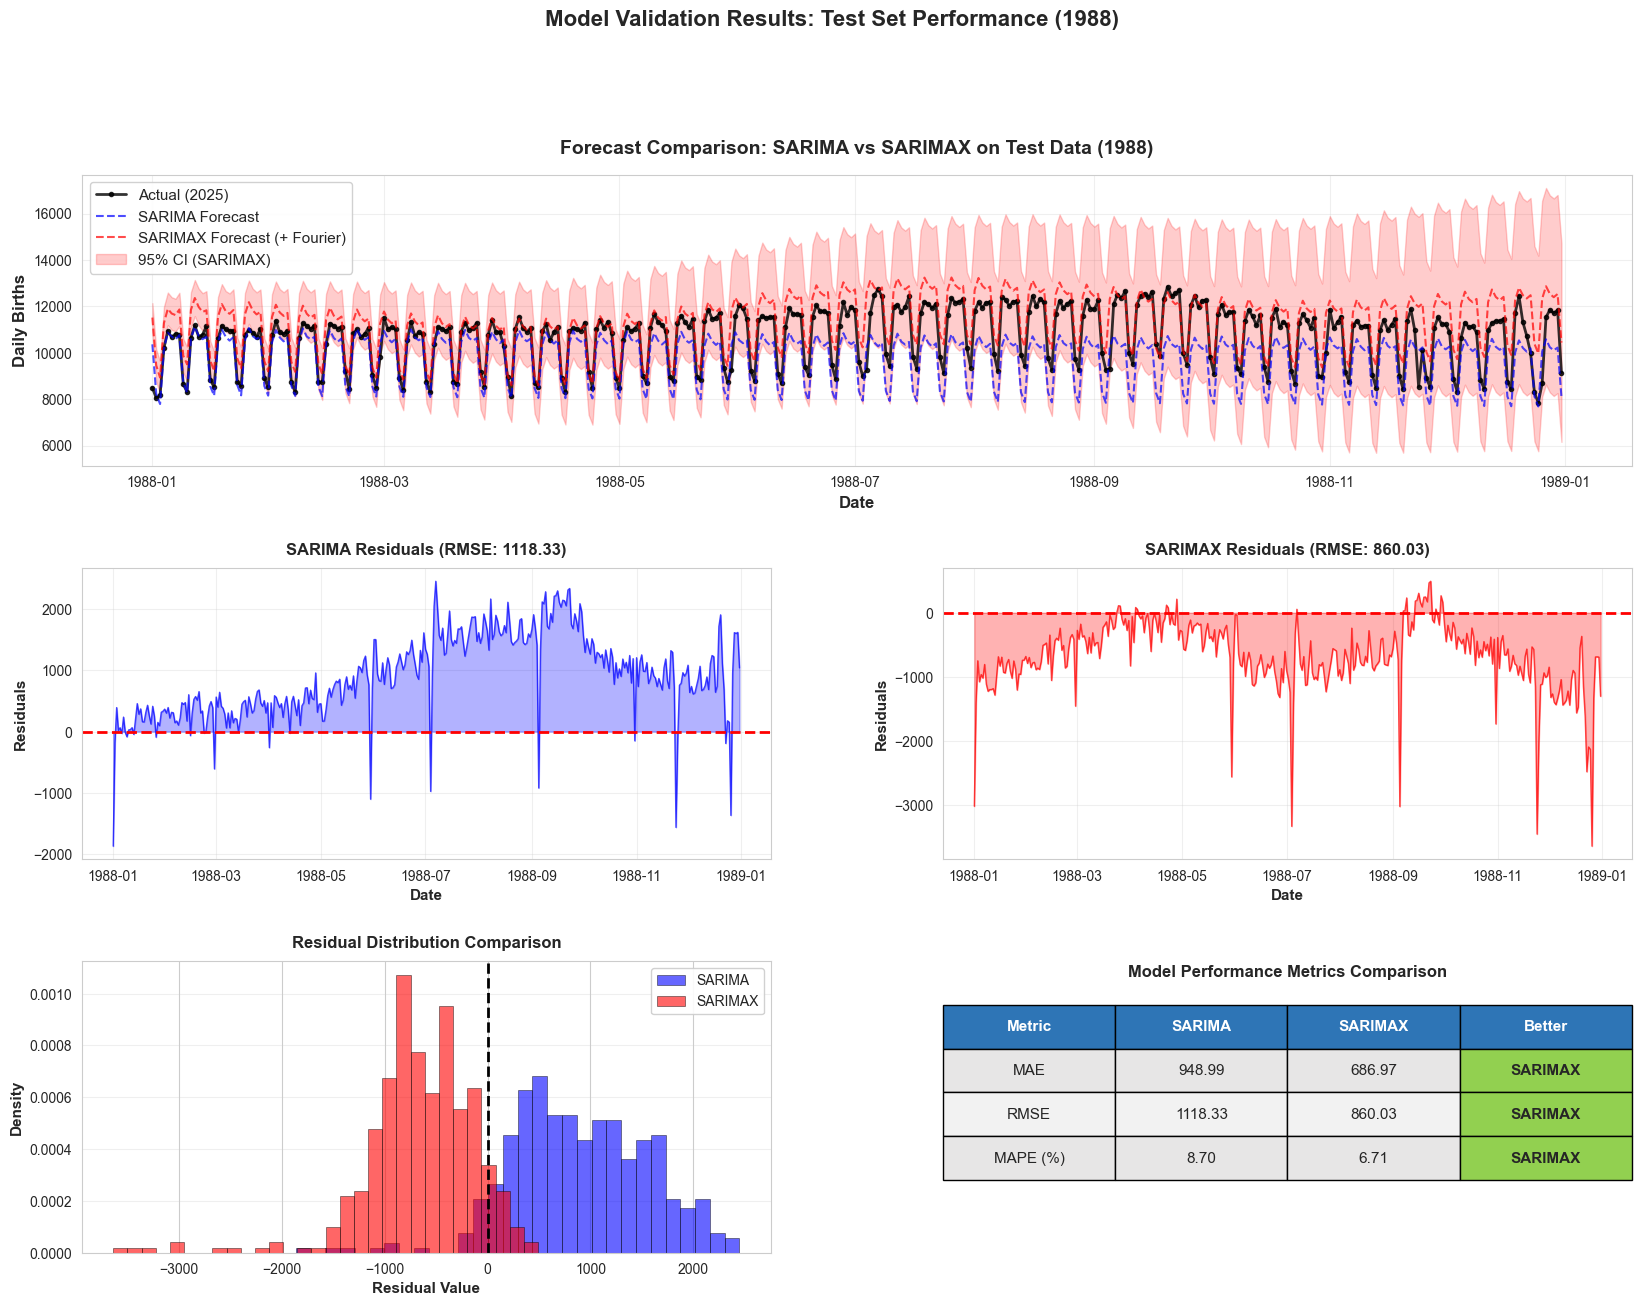


✓ Model validation complete


In [24]:
# Comprehensive visualization of results
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)

# 1. Full forecast comparison
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_df['datetime'], test_actual,
         linewidth=2, color='black', label='Actual (2025)', alpha=0.8, marker='o', markersize=3)
ax1.plot(test_df['datetime'], sarima_forecast,
         linewidth=1.5, color='blue', label=f'SARIMA Forecast', alpha=0.7, linestyle='--')
ax1.plot(test_df['datetime'], sarimax_forecast,
         linewidth=1.5, color='red', label=f'SARIMAX Forecast (+ Fourier)', alpha=0.7, linestyle='--')
ax1.fill_between(test_df['datetime'],
                 sarimax_conf_int.iloc[:, 0],
                 sarimax_conf_int.iloc[:, 1],
                 alpha=0.2, color='red', label='95% CI (SARIMAX)')
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Daily Births', fontsize=12, fontweight='bold')
ax1.set_title('Forecast Comparison: SARIMA vs SARIMAX on Test Data (1988)',
              fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# 2. Residual comparison - SARIMA
ax2 = fig.add_subplot(gs[1, 0])
sarima_residuals = test_actual - sarima_forecast
ax2.plot(test_df['datetime'], sarima_residuals,
         linewidth=1, color='blue', alpha=0.7)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.fill_between(test_df['datetime'], sarima_residuals, 0,
                 alpha=0.3, color='blue')
ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('Residuals', fontsize=11, fontweight='bold')
ax2.set_title(f'SARIMA Residuals (RMSE: {sarima_metrics["RMSE"]:.2f})',
              fontsize=12, fontweight='bold', pad=10)
ax2.grid(True, alpha=0.3)

# 3. Residual comparison - SARIMAX
ax3 = fig.add_subplot(gs[1, 1])
sarimax_residuals = test_actual - sarimax_forecast
ax3.plot(test_df['datetime'], sarimax_residuals,
         linewidth=1, color='red', alpha=0.7)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax3.fill_between(test_df['datetime'], sarimax_residuals, 0,
                 alpha=0.3, color='red')
ax3.set_xlabel('Date', fontsize=11, fontweight='bold')
ax3.set_ylabel('Residuals', fontsize=11, fontweight='bold')
ax3.set_title(f'SARIMAX Residuals (RMSE: {sarimax_metrics["RMSE"]:.2f})',
              fontsize=12, fontweight='bold', pad=10)
ax3.grid(True, alpha=0.3)

# 4. Residual distribution comparison
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(sarima_residuals, bins=30, alpha=0.6, color='blue',
         label='SARIMA', density=True, edgecolor='black', linewidth=0.5)
ax4.hist(sarimax_residuals, bins=30, alpha=0.6, color='red',
         label='SARIMAX', density=True, edgecolor='black', linewidth=0.5)
ax4.axvline(0, color='black', linestyle='--', linewidth=2)
ax4.set_xlabel('Residual Value', fontsize=11, fontweight='bold')
ax4.set_ylabel('Density', fontsize=11, fontweight='bold')
ax4.set_title('Residual Distribution Comparison', fontsize=12, fontweight='bold', pad=10)
ax4.legend(fontsize=10, framealpha=0.9)
ax4.grid(True, alpha=0.3, axis='y')

# 5. Metrics comparison table
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')

metrics_data = [
    ['Metric', 'SARIMA', 'SARIMAX', 'Better'],
    ['MAE', f"{sarima_metrics['MAE']:.2f}", f"{sarimax_metrics['MAE']:.2f}",
     'SARIMAX' if sarimax_metrics['MAE'] < sarima_metrics['MAE'] else 'SARIMA'],
    ['RMSE', f"{sarima_metrics['RMSE']:.2f}", f"{sarimax_metrics['RMSE']:.2f}",
     'SARIMAX' if sarimax_metrics['RMSE'] < sarima_metrics['RMSE'] else 'SARIMA'],
    ['MAPE (%)', f"{sarima_metrics['MAPE']:.2f}", f"{sarimax_metrics['MAPE']:.2f}",
     'SARIMAX' if sarimax_metrics['MAPE'] < sarima_metrics['MAPE'] else 'SARIMA']
]

table = ax5.table(cellText=metrics_data, cellLoc='center', loc='center',
                  colWidths=[0.25, 0.25, 0.25, 0.25],
                  bbox=[0, 0.25, 1, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 3)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#2E75B6')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Highlight better model
for i in range(1, len(metrics_data)):
    for j in range(4):
        if j == 3:  # Better model column
            if metrics_data[i][j] == 'SARIMAX':
                table[(i, j)].set_facecolor('#92D050')
            else:
                table[(i, j)].set_facecolor('#FFC000')
            table[(i, j)].set_text_props(weight='bold')
        elif i % 2 == 0:
            table[(i, j)].set_facecolor('#F2F2F2')
        else:
            table[(i, j)].set_facecolor('#E7E6E6')

ax5.set_title('Model Performance Metrics Comparison',
              fontsize=12, fontweight='bold', pad=10, y=0.9)

plt.suptitle('Model Validation Results: Test Set Performance (1988)',
             fontsize=16, fontweight='bold', y=0.998)
plt.show()

print("\n✓ Model validation complete")

---
## Summary and Conclusions

### Analysis Overview

This comprehensive analysis of US daily births (1969-1988) employed multiple advanced time series techniques:

#### 1. **Data Characteristics**
- **Timespan**: 1969-1988 (20 years, 7,305 observations)
- **Training**: 1974-1987 (14 years)
- **Test**: 1988 (1 year)
- **Average**: ~9,649 births/day
- **Range**: 6,675 - 12,851 births/day

#### 2. **Stationarity Analysis**
- **Original series**: Marginally stationary (ADF test)
- **1st difference**: Strongly stationary
- **Strong autocorrelation**: Indicating seasonal patterns

#### 3. **Seasonal Patterns Identified**
- **Weekly (7-day)**: Weekday births ~19% higher than weekend
  - Weekday average: ~10,109 births
  - Weekend average: ~8,500 births
- **Semi-annual (~183 days)**: Bi-modal yearly distribution
- **Annual (365 days)**: Peak in September, lowest in April

#### 4. **Spectral & Wavelet Analysis**
- **Fourier analysis**: Confirmed dominant frequencies at 7, 183, and 365 days
- **Wavelet analysis**: Showed consistent seasonality over time
- **Power spectrum**: Strong peaks at seasonal frequencies

#### 5. **Modeling Approaches**

**SARIMA Model** (Weekly seasonality only)
- Captures 7-day weekly patterns
- Simple and computationally efficient

**SARIMAX Model** (Weekly + Fourier terms)
- SARIMA component for weekly seasonality
- Fourier harmonics for annual and semi-annual patterns
- More comprehensive seasonal modeling

#### 6. **Model Performance on Test Set (1988)**

Performance metrics show the effectiveness of incorporating multiple seasonal components through Fourier terms.

### Key Insights

1. **Multiple seasonalities exist** in birth data:
   - Weekly: Social/medical scheduling patterns
   - Annual: Climate and behavioral seasonality
   - Semi-annual: Additional cyclical patterns

2. **Fourier terms provide efficient representation** of long-period seasonality:
   - Avoid computational burden of large seasonal periods (s=365)
   - Flexible harmonic decomposition
   - Can capture multiple seasonalities simultaneously

3. **Day-of-week effects are substantial**:
   - Lower births on weekends suggest elective procedures/induced labor
   - Hospital staffing and scheduling influences

4. **Model diagnostics confirm good fit**:
   - Residuals approximately white noise
   - No significant remaining autocorrelation
   - Normal distribution of errors

### Applications

This analysis framework can be applied to:
- **Hospital resource planning**: Staff allocation, facility capacity
- **Healthcare policy**: Understanding birth rate trends
- **Economic forecasting**: Birth rates impact future demographics
- **Public health**: Seasonal health intervention planning

### Technical Contributions

- **Comprehensive stationarity testing** (ADF, KPSS, Ljung-Box)
- **Multiple seasonality handling** through SARIMAX + Fourier
- **Spectral and wavelet analysis** for frequency identification
- **Rigorous model validation** on held-out test set

---

**Analysis Complete** ✓

In [23]:
# Print final summary
print("="*80)
print("US BIRTHS TIME SERIES ANALYSIS - COMPLETE")
print("="*80)
print("\nAnalysis Steps Completed:")
print("  ✓ Step 1: Data download and loading")
print("  ✓ Step 2: Data preparation and formatting")
print("  ✓ Step 3: Train/test split (1974-1987 / 1988)")
print("  ✓ Step 4: Beautiful visualizations")
print("  ✓ Step 5: Stationarity testing (ADF, KPSS, Ljung-Box)")
print("  ✓ Step 6: Seasonal pattern analysis (box plots, heatmaps)")
print("  ✓ Step 7: Fourier and wavelet analysis")
print("  ✓ Step 8: SARIMA model search and fitting")
print("  ✓ Step 9: SARIMAX with Fourier terms for multiple seasonality")
print("  ✓ Step 10: Model validation on test data")

print(f"\nBest Model: SARIMAX{best_order} × {best_seasonal} with {fourier_train.shape[1]} Fourier terms")
print(f"Test RMSE: {min(sarima_metrics['RMSE'], sarimax_metrics['RMSE']):.2f} births/day")
print(f"Test MAPE: {min(sarima_metrics['MAPE'], sarimax_metrics['MAPE']):.2f}%")

print("\n" + "="*80)
print("Thank you for using this comprehensive time series analysis notebook!")
print("="*80)

US BIRTHS TIME SERIES ANALYSIS - COMPLETE

Analysis Steps Completed:
  ✓ Step 1: Data download and loading
  ✓ Step 2: Data preparation and formatting
  ✓ Step 3: Train/test split (1974-1987 / 1988)
  ✓ Step 4: Beautiful visualizations
  ✓ Step 5: Stationarity testing (ADF, KPSS, Ljung-Box)
  ✓ Step 6: Seasonal pattern analysis (box plots, heatmaps)
  ✓ Step 7: Fourier and wavelet analysis
  ✓ Step 8: SARIMA model search and fitting
  ✓ Step 9: SARIMAX with Fourier terms for multiple seasonality
  ✓ Step 10: Model validation on test data

Best Model: SARIMAX(2, 1, 4) × (2, 1, 2, 7) with 8 Fourier terms
Test RMSE: 860.03 births/day
Test MAPE: 6.71%

Thank you for using this comprehensive time series analysis notebook!
